# 강원도 산불-날씨 EDA: 시각화 중심 재분석

## 분석 질문
1. 산불 발생 시점의 날씨 분포는 어떤가?
2. 강원도 `영동 해안형 / 영서 내륙형 / 고지·산간형` 기후지형유형별 날씨 분포는 어떻게 다른가?
3. 산불이 일어난 시점과 안 일어난 시점의 날씨 차이는 통계적으로 확인되는가?

## 이번 노트북의 출력 원칙
- 대용량 DataFrame 원문 출력은 하지 않는다.
- 사용자가 바로 해석할 수 있도록 지도, 분포도, 히트맵, 효과크기 그래프를 우선 사용한다.
- 세 기후지형유형의 순서와 색은 모든 그래프에서 고정한다.
- 통계 검정은 결론의 근거로 사용하고, 결과는 효과크기와 FDR 보정 q-value 중심으로 시각화한다.
        

## 고정 색상과 순서

모든 그래프에서 아래 순서와 색상을 유지한다.

1. `영동 해안형` - 파란색
2. `영서 내륙형` - 초록색
3. `고지·산간형` - 주황색

이 순서는 노트북 전체에서 `TYPE_ORDER`와 `TYPE_PALETTE`로 고정한다.
        

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

try:
    from IPython.display import display, Markdown
except Exception:
    display = print

    def Markdown(text):
        return text


font_path = "C:/Windows/Fonts/malgun.ttf"
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
else:
    font_name = "DejaVu Sans"

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False,
    },
)
plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 30)

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents, Path("D:/farm-system-public-02")]:
    if (candidate / "data").exists() and (candidate / "jsw").exists():
        ROOT = candidate
        break

WEATHER_DIR = ROOT / "data" / "강원도_날씨데이터"
FIRE_DIR = ROOT / "data" / "강원도_데이터"
RANDOM_STATE = 42

TYPE_ORDER = ["영동 해안형", "영서 내륙형", "고지·산간형"]
TYPE_PALETTE = {
    "영동 해안형": "#2A6FBB",
    "영서 내륙형": "#2E8B57",
    "고지·산간형": "#C97A28",
}
TYPE_COLORS = [TYPE_PALETTE[t] for t in TYPE_ORDER]
REGION_ORDER = ["영동", "영서"]
FIRE_CONTROL_ORDER = ["산불", "매칭 비발생"]
FIRE_CONTROL_PALETTE = {"산불": "#D1495B", "매칭 비발생": "#4C78A8"}


def set_type_order(df, col="기후지형유형"):
    out = df.copy()
    if col in out.columns:
        out[col] = pd.Categorical(out[col], categories=TYPE_ORDER, ordered=True)
    return out


def add_value_labels(ax, fmt="{:.0f}", rotation=0, padding=2):
    for patch in ax.patches:
        height = patch.get_height()
        if not np.isfinite(height):
            continue
        ax.annotate(
            fmt.format(height),
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=rotation,
            xytext=(0, padding),
            textcoords="offset points",
        )


def savefig_show():
    plt.tight_layout()
    plt.show()


print("ROOT:", ROOT)
print("matplotlib font:", plt.rcParams["font.family"])
        

ROOT: d:\farm-system-public-02
matplotlib font: ['Malgun Gothic']


## 1. 데이터 로드와 분석용 테이블 구성

In [2]:
cells = pd.read_csv(WEATHER_DIR / "강원도날씨_격자.csv", encoding="utf-8-sig")
terrain = pd.read_csv(WEATHER_DIR / "강원도날씨_기후지형유형_셀분류.csv", encoding="utf-8-sig")
daily_raw = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_일단위.csv", encoding="utf-8-sig")
hourly_raw = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_시간단위.csv", encoding="utf-8-sig")
fire_raw = pd.read_csv(FIRE_DIR / "강원도_산불발생.csv", encoding="utf-8-sig")
grid = gpd.read_file(WEATHER_DIR / "강원도날씨_격자.geojson")
if grid.crs is None:
    grid = grid.set_crs("EPSG:4326")

terrain = set_type_order(terrain)
cells = set_type_order(cells.merge(terrain[["기상셀ID", "기후지형유형"]], on="기상셀ID", how="left"))
grid = set_type_order(grid.merge(terrain[["기상셀ID", "기후지형유형"]], on="기상셀ID", how="left"))


def add_fire_datetime(fire):
    out = fire.copy()
    out["발생일시"] = pd.to_datetime(
        dict(year=out["연도"], month=out["월"], day=out["일"], hour=out["시간"]),
        errors="coerce",
    )
    out["날짜"] = out["발생일시"].dt.normalize()
    out["전일"] = out["날짜"] - pd.Timedelta(days=1)
    out["월_key"] = out["발생일시"].dt.month
    out["시간_key"] = out["발생일시"].dt.hour
    return out


def spatial_join_fire(fire, grid, terrain):
    fire = add_fire_datetime(fire)
    fire_gdf = gpd.GeoDataFrame(
        fire,
        geometry=gpd.points_from_xy(fire["경도"], fire["위도"]),
        crs="EPSG:4326",
    )
    joined = gpd.sjoin(
        fire_gdf,
        grid[["기상셀ID", "기후권역", "geometry"]],
        how="left",
        predicate="within",
    ).drop(columns=["index_right"])
    unmatched = joined[joined["기상셀ID"].isna()].copy()
    matched = joined[joined["기상셀ID"].notna()].copy()
    matched = matched.merge(terrain[["기상셀ID", "기후지형유형"]], on="기상셀ID", how="left")
    return set_type_order(matched.drop(columns=["geometry"])), unmatched.drop(columns=["geometry"])


def prepare_weather(daily, hourly, terrain):
    terrain_cols = terrain[["기상셀ID", "기후권역", "기후지형유형"]]
    daily = daily.copy()
    daily["날짜"] = pd.to_datetime(daily["날짜"])
    daily["월"] = daily["날짜"].dt.month
    daily["일교차_C"] = daily["최고기온_C"] - daily["최저기온_C"]
    daily["서풍계열_최대순간풍향"] = daily["최대순간풍향_deg"].between(225, 315, inclusive="both")
    daily["최대순간풍향_sin"] = np.sin(np.deg2rad(daily["최대순간풍향_deg"]))
    daily["최대순간풍향_cos"] = np.cos(np.deg2rad(daily["최대순간풍향_deg"]))
    daily = set_type_order(daily.merge(terrain_cols, on="기상셀ID", how="left"))

    hourly = hourly.copy()
    hourly["일시"] = pd.to_datetime(hourly["일시"])
    hourly["날짜"] = hourly["일시"].dt.normalize()
    hourly["월"] = hourly["일시"].dt.month
    hourly["시간"] = hourly["일시"].dt.hour
    hourly["서풍계열_풍향"] = hourly["풍향_deg"].between(225, 315, inclusive="both")
    hourly["풍향_sin"] = np.sin(np.deg2rad(hourly["풍향_deg"]))
    hourly["풍향_cos"] = np.cos(np.deg2rad(hourly["풍향_deg"]))
    hourly = set_type_order(hourly.merge(terrain_cols, on="기상셀ID", how="left"))
    return daily, hourly


def add_prior_24h(hourly):
    hourly = hourly.sort_values(["기상셀ID", "일시"]).copy()
    shifted = hourly.groupby("기상셀ID")[
        ["기온_C", "풍속_m_s", "습도_pct", "강수량_mm", "현지기압_hPa", "해면기압_hPa"]
    ].shift(1)
    base = pd.DataFrame(index=hourly.index)
    base["직전24h_평균기온_C"] = shifted["기온_C"].groupby(hourly["기상셀ID"]).rolling(24, min_periods=24).mean().reset_index(level=0, drop=True)
    base["직전24h_평균풍속_m_s"] = shifted["풍속_m_s"].groupby(hourly["기상셀ID"]).rolling(24, min_periods=24).mean().reset_index(level=0, drop=True)
    base["직전24h_최대풍속_m_s"] = shifted["풍속_m_s"].groupby(hourly["기상셀ID"]).rolling(24, min_periods=24).max().reset_index(level=0, drop=True)
    base["직전24h_최소습도_pct"] = shifted["습도_pct"].groupby(hourly["기상셀ID"]).rolling(24, min_periods=24).min().reset_index(level=0, drop=True)
    base["직전24h_강수량합_mm"] = shifted["강수량_mm"].groupby(hourly["기상셀ID"]).rolling(24, min_periods=24).sum().reset_index(level=0, drop=True)
    base["직전24h_평균현지기압_hPa"] = shifted["현지기압_hPa"].groupby(hourly["기상셀ID"]).rolling(24, min_periods=24).mean().reset_index(level=0, drop=True)
    base["직전24h_평균해면기압_hPa"] = shifted["해면기압_hPa"].groupby(hourly["기상셀ID"]).rolling(24, min_periods=24).mean().reset_index(level=0, drop=True)
    return pd.concat([hourly, base], axis=1)


fire_cells, unmatched_fire = spatial_join_fire(fire_raw, grid, terrain)
daily, hourly = prepare_weather(daily_raw, hourly_raw, terrain)
hourly24 = add_prior_24h(hourly)

assert len(cells) == 92
assert len(fire_raw) == 3405
assert len(unmatched_fire) == 4
assert len(fire_cells) == 3401
        

### 데이터 사용 요약
- **기상셀**: 92개  
- **일단위 날씨**: 67,252행  
- **시간단위 날씨**: 1,614,048행  
- **원 산불**: 3,405건  
- **미매칭 제거**: 4건  
- **분석 산불**: 3,401건

미매칭 제거 fire_id: `F_006690, F_009678, F_010665, F_010893`

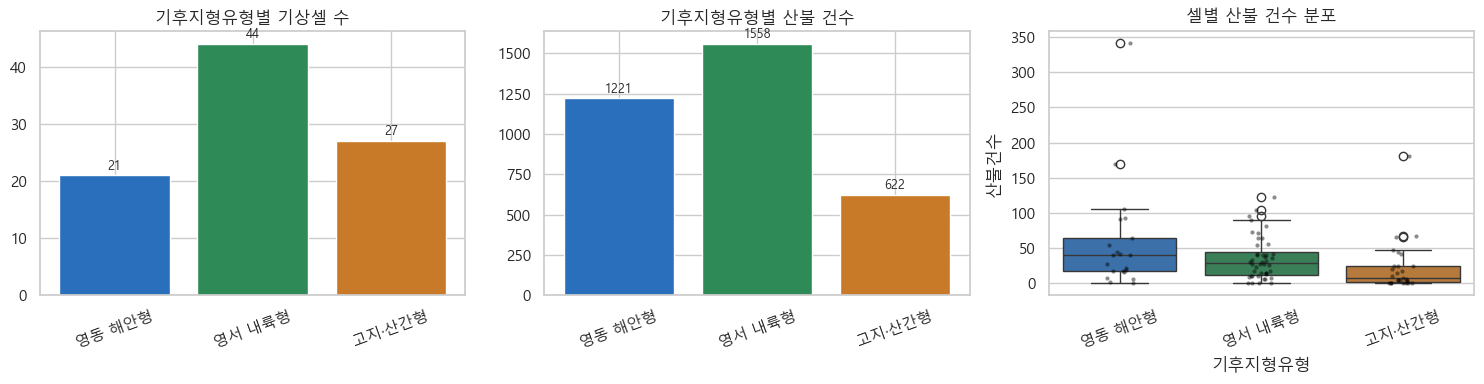

In [3]:
cards = {
    "기상셀": f"{len(cells):,}개",
    "일단위 날씨": f"{len(daily):,}행",
    "시간단위 날씨": f"{len(hourly):,}행",
    "원 산불": f"{len(fire_raw):,}건",
    "미매칭 제거": f"{len(unmatched_fire):,}건",
    "분석 산불": f"{len(fire_cells):,}건",
}
card_text = "  \n".join([f"- **{k}**: {v}" for k, v in cards.items()])
unmatched_ids = ", ".join(unmatched_fire["fire_id"].tolist())
display(Markdown(f"### 데이터 사용 요약\n{card_text}\n\n미매칭 제거 fire_id: `{unmatched_ids}`"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cell_counts = cells["기후지형유형"].value_counts().reindex(TYPE_ORDER)
fire_counts = fire_cells["기후지형유형"].value_counts().reindex(TYPE_ORDER)
fire_per_cell = (
    fire_cells.groupby("기상셀ID").size().rename("산불건수")
    .reindex(cells["기상셀ID"], fill_value=0)
    .reset_index(drop=True)
)
cell_fire_counts = cells[["기상셀ID", "기후지형유형"]].copy()
cell_fire_counts["산불건수"] = fire_per_cell

axes[0].bar(TYPE_ORDER, cell_counts.values, color=TYPE_COLORS)
axes[0].set_title("기후지형유형별 기상셀 수")
axes[0].tick_params(axis="x", rotation=20)
add_value_labels(axes[0])

axes[1].bar(TYPE_ORDER, fire_counts.values, color=TYPE_COLORS)
axes[1].set_title("기후지형유형별 산불 건수")
axes[1].tick_params(axis="x", rotation=20)
add_value_labels(axes[1])

sns.boxplot(
    data=cell_fire_counts,
    x="기후지형유형",
    y="산불건수",
    order=TYPE_ORDER,
    palette=TYPE_PALETTE,
    ax=axes[2],
)
sns.stripplot(
    data=cell_fire_counts,
    x="기후지형유형",
    y="산불건수",
    order=TYPE_ORDER,
    color="black",
    alpha=0.45,
    size=3,
    ax=axes[2],
)
axes[2].set_title("셀별 산불 건수 분포")
axes[2].tick_params(axis="x", rotation=20)
savefig_show()
        

## 2. 공간·시간 분포 EDA

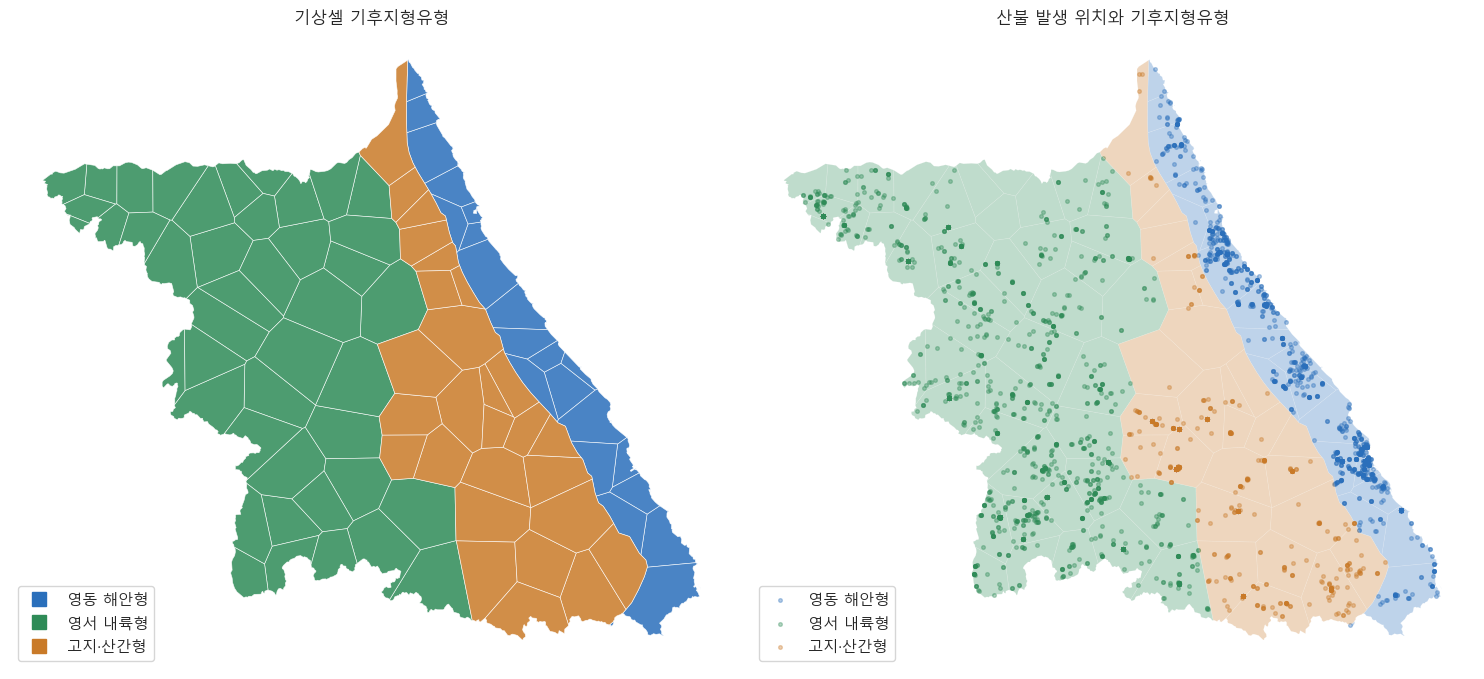

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for t in TYPE_ORDER:
    grid.loc[grid["기후지형유형"] == t].plot(
        ax=axes[0],
        color=TYPE_PALETTE[t],
        edgecolor="white",
        linewidth=0.45,
        alpha=0.85,
    )
axes[0].set_title("기상셀 기후지형유형")
axes[0].set_axis_off()
handles = [plt.Line2D([0], [0], marker="s", linestyle="", color=TYPE_PALETTE[t], label=t, markersize=10) for t in TYPE_ORDER]
axes[0].legend(handles=handles, loc="lower left")

for t in TYPE_ORDER:
    grid.loc[grid["기후지형유형"] == t].plot(
        ax=axes[1],
        color=TYPE_PALETTE[t],
        edgecolor="white",
        linewidth=0.35,
        alpha=0.3,
    )
    tmp = fire_cells.loc[fire_cells["기후지형유형"] == t]
    axes[1].scatter(tmp["경도"], tmp["위도"], s=7, alpha=0.35, color=TYPE_PALETTE[t], label=t)
axes[1].set_title("산불 발생 위치와 기후지형유형")
axes[1].set_axis_off()
axes[1].legend(loc="lower left")
savefig_show()
        

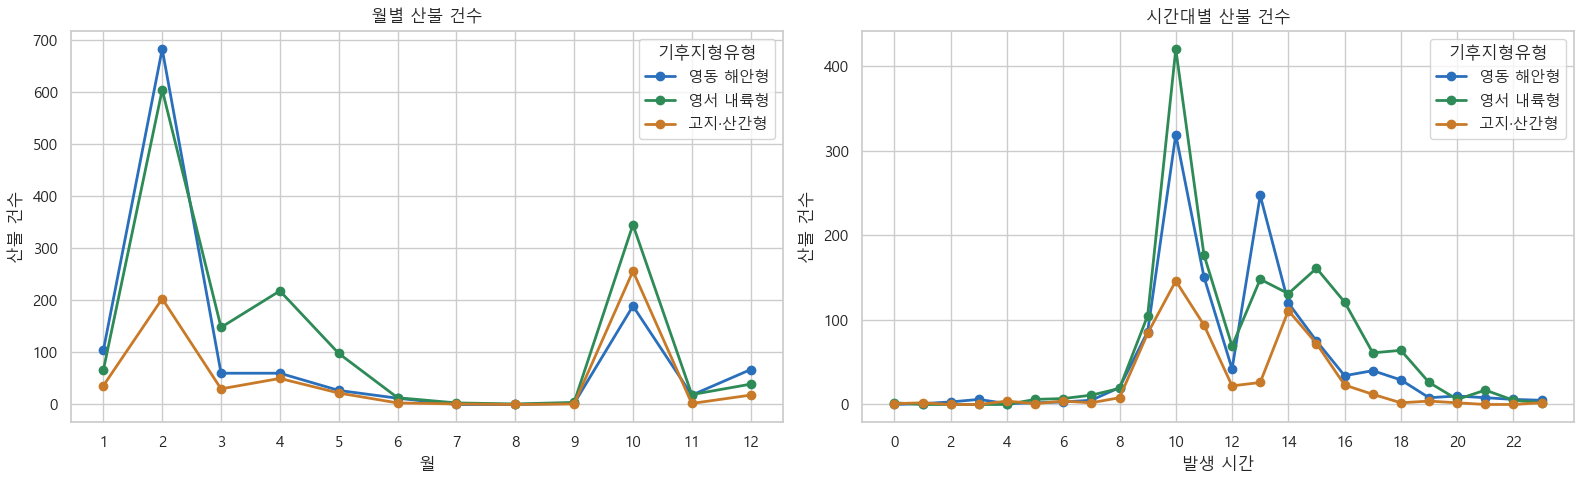

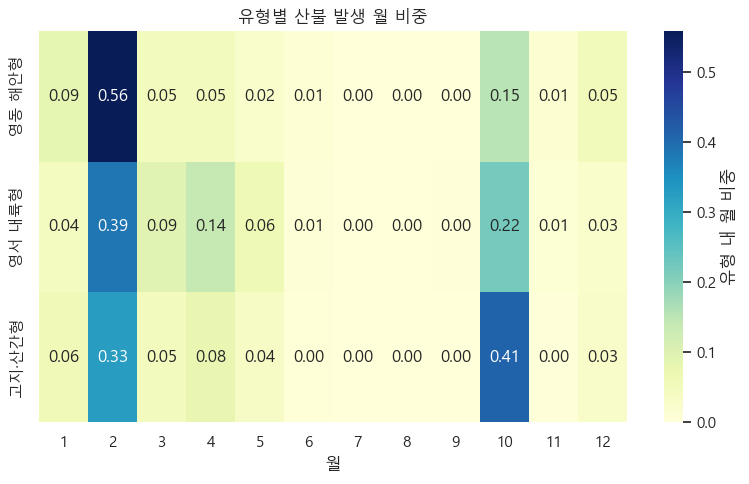

In [5]:
month_counts = (
    fire_cells.groupby(["월", "기후지형유형"], observed=False)
    .size()
    .rename("산불건수")
    .reset_index()
)

hour_counts = (
    fire_cells.groupby(["시간", "기후지형유형"], observed=False)
    .size()
    .rename("산불건수")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 월별 산불 건수 (꺾은선 그래프)
for t in TYPE_ORDER:
    part = (
        month_counts.loc[month_counts["기후지형유형"] == t]
        .set_index("월")
        .reindex(range(1, 13), fill_value=0)
    )

    axes[0].plot(
        part.index,
        part["산불건수"],
        marker="o",
        linewidth=2,
        color=TYPE_PALETTE[t],
        label=t,
    )

axes[0].set_title("월별 산불 건수")
axes[0].set_xlabel("월")
axes[0].set_ylabel("산불 건수")
axes[0].set_xticks(range(1, 13))
axes[0].legend(title="기후지형유형")


# 시간대별 산불 건수 (기존 유지)
for t in TYPE_ORDER:
    part = (
        hour_counts.loc[hour_counts["기후지형유형"] == t]
        .set_index("시간")
        .reindex(range(24), fill_value=0)
    )

    axes[1].plot(
        part.index,
        part["산불건수"],
        marker="o",
        linewidth=2,
        color=TYPE_PALETTE[t],
        label=t,
    )

axes[1].set_title("시간대별 산불 건수")
axes[1].set_xlabel("발생 시간")
axes[1].set_ylabel("산불 건수")
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend(title="기후지형유형")

savefig_show()


# 히트맵
month_pivot = (
    month_counts.pivot(
        index="월",
        columns="기후지형유형",
        values="산불건수"
    )
    .reindex(columns=TYPE_ORDER)
    .fillna(0)
)

month_norm = month_pivot.div(month_pivot.sum(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    month_norm.T,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "유형 내 월 비중"},
    ax=ax,
)

ax.set_title("유형별 산불 발생 월 비중")
ax.set_xlabel("월")
ax.set_ylabel("")

savefig_show()

기존의 통념과는 다르게, 이전 분석에서는 전국적으로는 11~5월에 산불이 많이 발생하였으나 강원도는 2월, 그리고 10월에만 많이 발생한다.  
영서는 3~5월에도 발생 횟수 및 비율이 영동과 산간형과 다르게 높다.  
내륙형과 해안형의 차이인가? 주의 깊게 봐야겠다. 이것이 우리의 분석의 킥이 될 수 있을 듯 하다.
또한 산간형의 경우 10월에 비율이 타 지역 대비 비율이 두배 이상 높다.

## 3. 강원도 전체 날씨 분포: 유형별 배경 조건

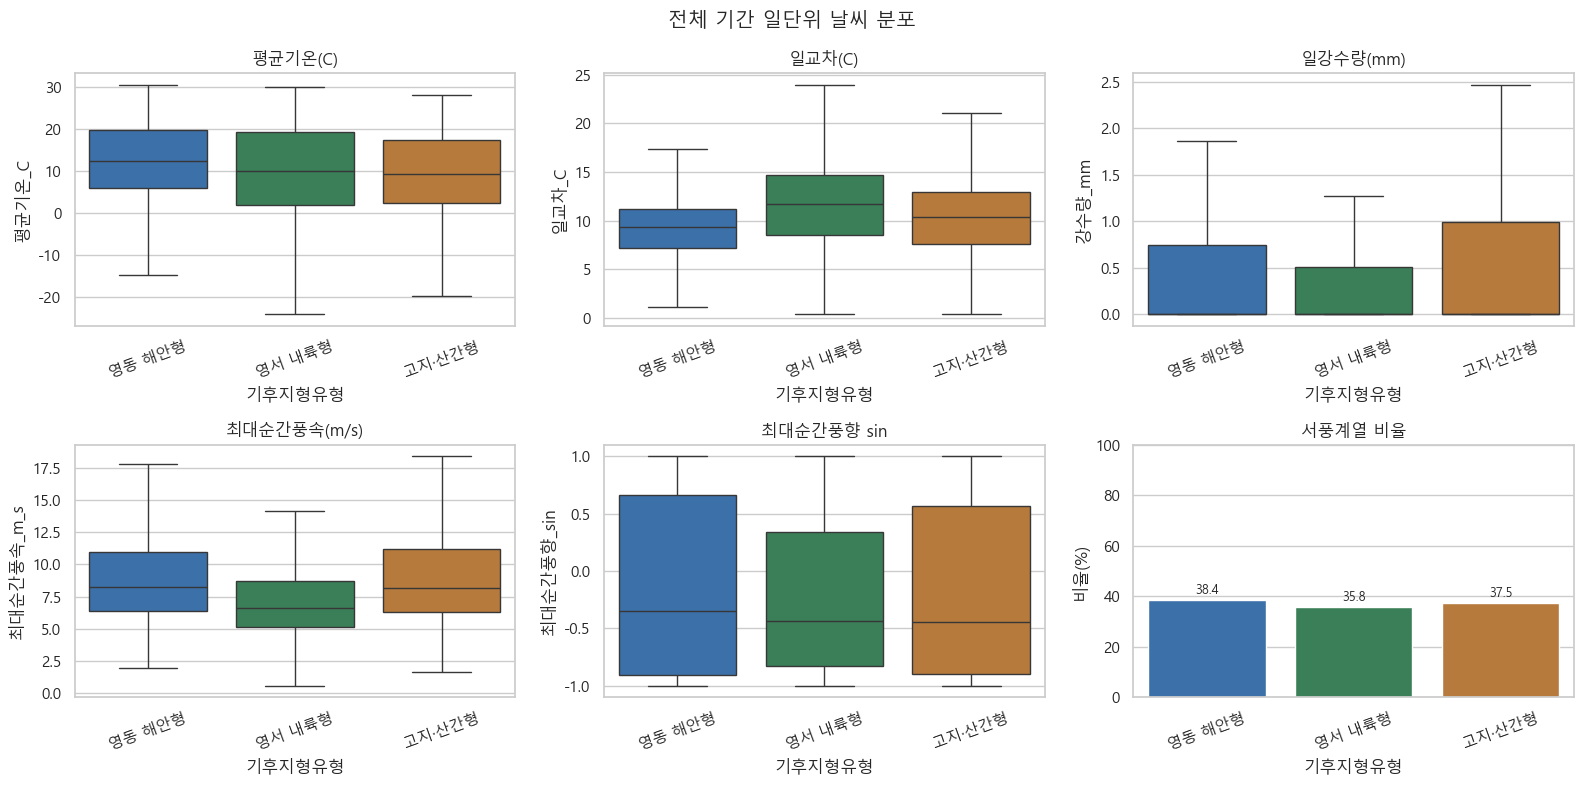

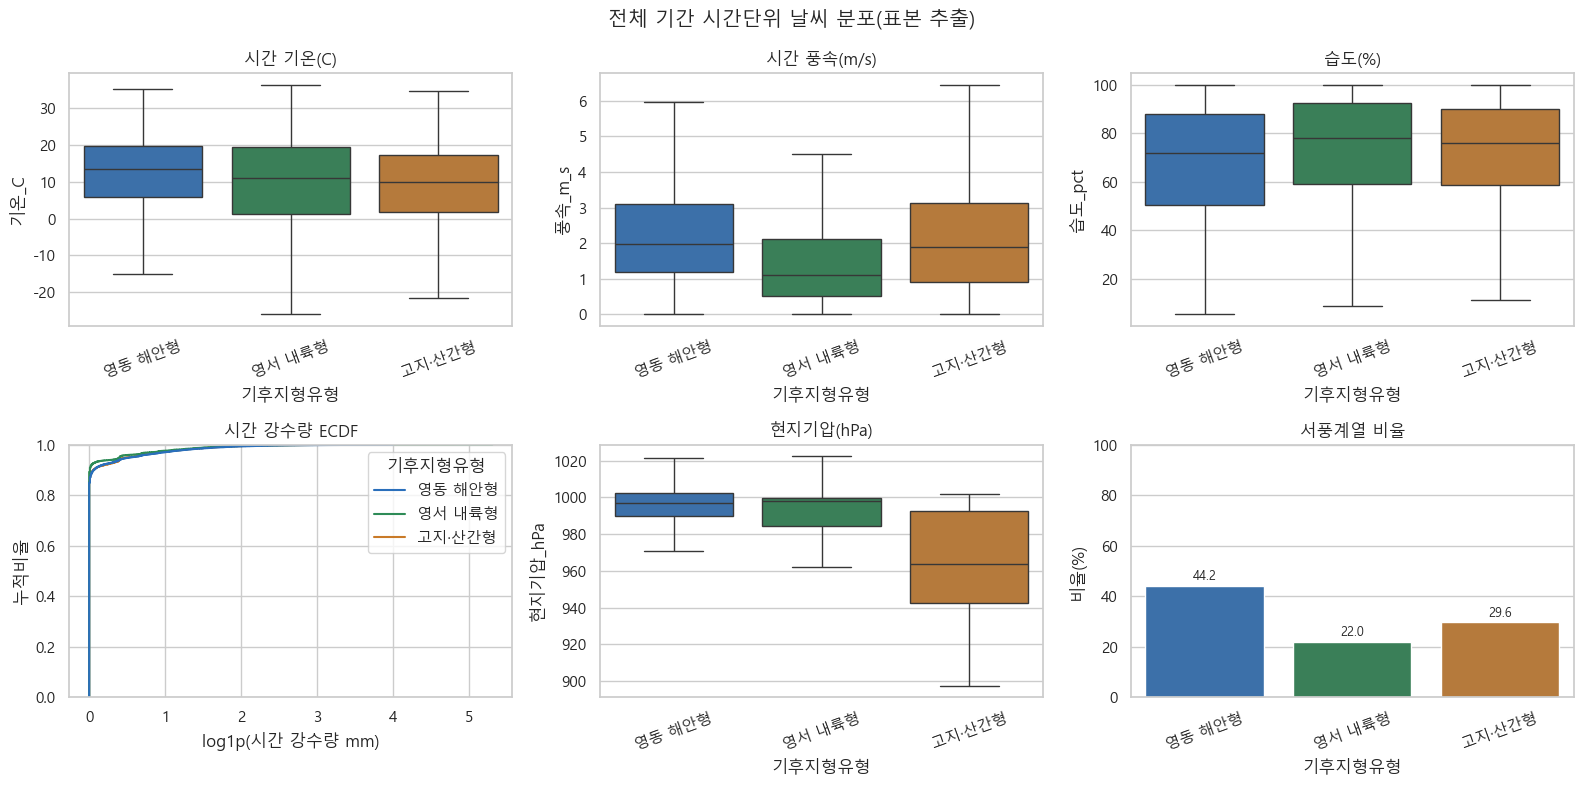

In [6]:
def boxplot_by_type(ax, data, col, title):
    sns.boxplot(
        data=data,
        x="기후지형유형",
        y=col,
        order=TYPE_ORDER,
        palette=TYPE_PALETTE,
        showfliers=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)


def rate_bar_by_type(ax, data, col, title):
    rate = (
        data.groupby("기후지형유형", observed=False)[col]
        .mean()
        .reindex(TYPE_ORDER)
        .mul(100)
        .rename("비율_pct")
        .reset_index()
    )

    sns.barplot(
        data=rate,
        x="기후지형유형",
        y="비율_pct",
        order=TYPE_ORDER,
        palette=TYPE_PALETTE,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_ylabel("비율(%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=20)
    add_value_labels(ax, fmt="{:.1f}")


daily_plot_vars = [
    ("평균기온_C", "평균기온(C)"),
    ("일교차_C", "일교차(C)"),
    ("강수량_mm", "일강수량(mm)"),
    ("최대순간풍속_m_s", "최대순간풍속(m/s)"),
    ("최대순간풍향_sin", "최대순간풍향 sin"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (col, title) in zip(axes.ravel()[:5], daily_plot_vars):
    boxplot_by_type(ax, daily, col, title)

rate_bar_by_type(
    axes.ravel()[5],
    daily,
    "서풍계열_최대순간풍향",
    "서풍계열 비율",
)

fig.suptitle("전체 기간 일단위 날씨 분포")
savefig_show()


hourly_sample = hourly.sample(180000, random_state=RANDOM_STATE)

hourly_plot_vars = [
    ("기온_C", "시간 기온(C)"),
    ("풍속_m_s", "시간 풍속(m/s)"),
    ("습도_pct", "습도(%)"),
    ("현지기압_hPa", "현지기압(hPa)"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

boxplot_by_type(axes[0, 0], hourly_sample, "기온_C", "시간 기온(C)")
boxplot_by_type(axes[0, 1], hourly_sample, "풍속_m_s", "시간 풍속(m/s)")
boxplot_by_type(axes[0, 2], hourly_sample, "습도_pct", "습도(%)")

rain_ecdf = hourly_sample[["기후지형유형", "강수량_mm"]].copy()
rain_ecdf["강수량_log1p"] = np.log1p(
    pd.to_numeric(rain_ecdf["강수량_mm"], errors="coerce").clip(lower=0)
)

sns.ecdfplot(
    data=rain_ecdf,
    x="강수량_log1p",
    hue="기후지형유형",
    hue_order=TYPE_ORDER,
    palette=TYPE_PALETTE,
    ax=axes[1, 0],
)
axes[1, 0].set_title("시간 강수량 ECDF")
axes[1, 0].set_xlabel("log1p(시간 강수량 mm)")
axes[1, 0].set_ylabel("누적비율")

boxplot_by_type(axes[1, 1], hourly_sample, "현지기압_hPa", "현지기압(hPa)")

rate_bar_by_type(
    axes[1, 2],
    hourly,
    "서풍계열_풍향",
    "서풍계열 비율",
)

fig.suptitle("전체 기간 시간단위 날씨 분포(표본 추출)")
savefig_show()

- ECDF : 경험적 누적분포함수 - x축 값 이하인 데이터가 전체의 몇 %인지 보여주는 그래프

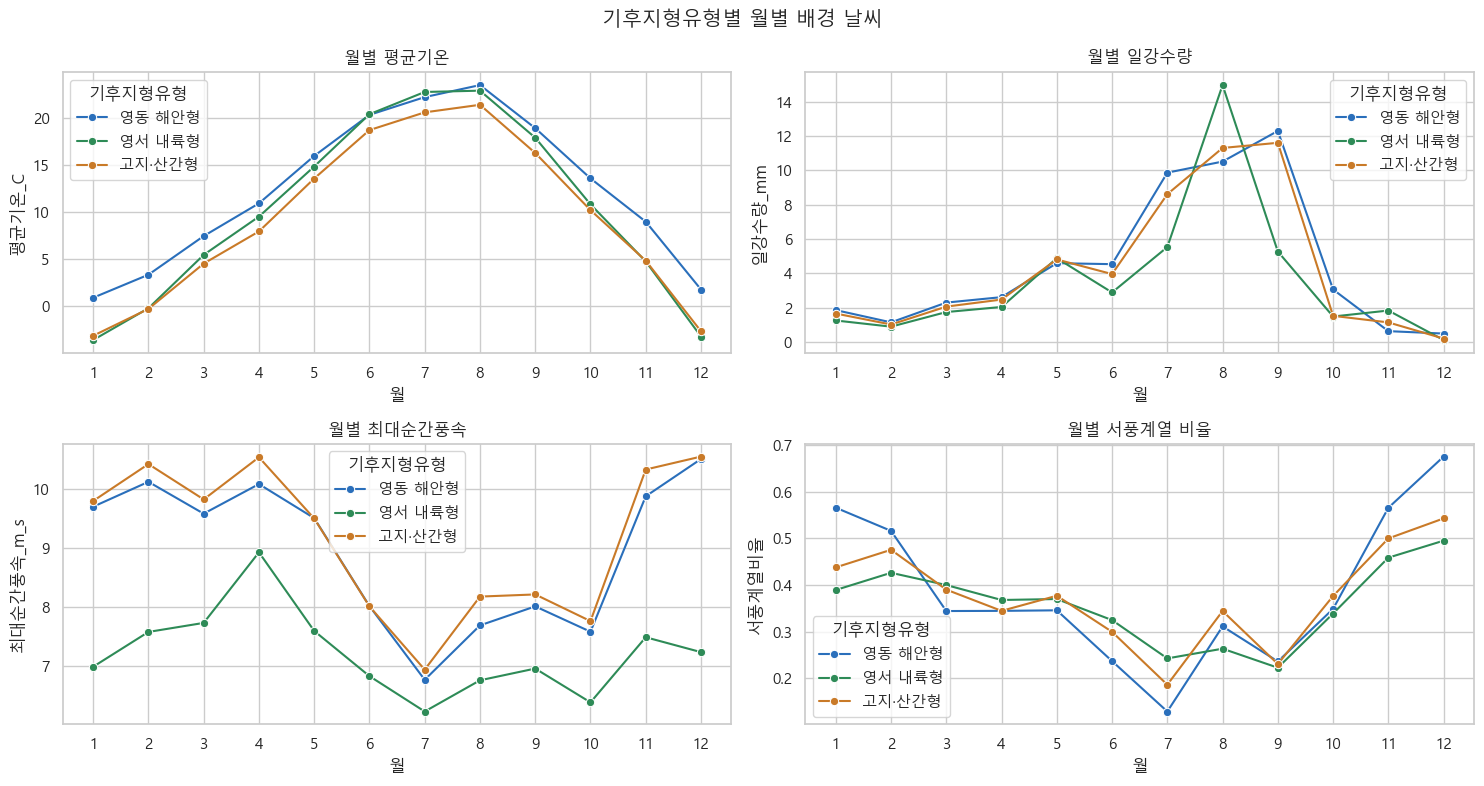

In [7]:
monthly_weather = (
    daily.groupby(["월", "기후지형유형"], observed=False)
    .agg(
        평균기온_C=("평균기온_C", "mean"),
        일강수량_mm=("강수량_mm", "mean"),
        최대순간풍속_m_s=("최대순간풍속_m_s", "mean"),
        서풍계열비율=("서풍계열_최대순간풍향", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, y, title in zip(
    axes.ravel(),
    ["평균기온_C", "일강수량_mm", "최대순간풍속_m_s", "서풍계열비율"],
    ["월별 평균기온", "월별 일강수량", "월별 최대순간풍속", "월별 서풍계열 비율"],
):
    sns.lineplot(
        data=monthly_weather,
        x="월",
        y=y,
        hue="기후지형유형",
        hue_order=TYPE_ORDER,
        palette=TYPE_PALETTE,
        marker="o",
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xticks(range(1, 13))
fig.suptitle("기후지형유형별 월별 배경 날씨")
savefig_show()
        

## 4. 산불 발생일·전일·발생시각·직전 24시간 날씨 분포

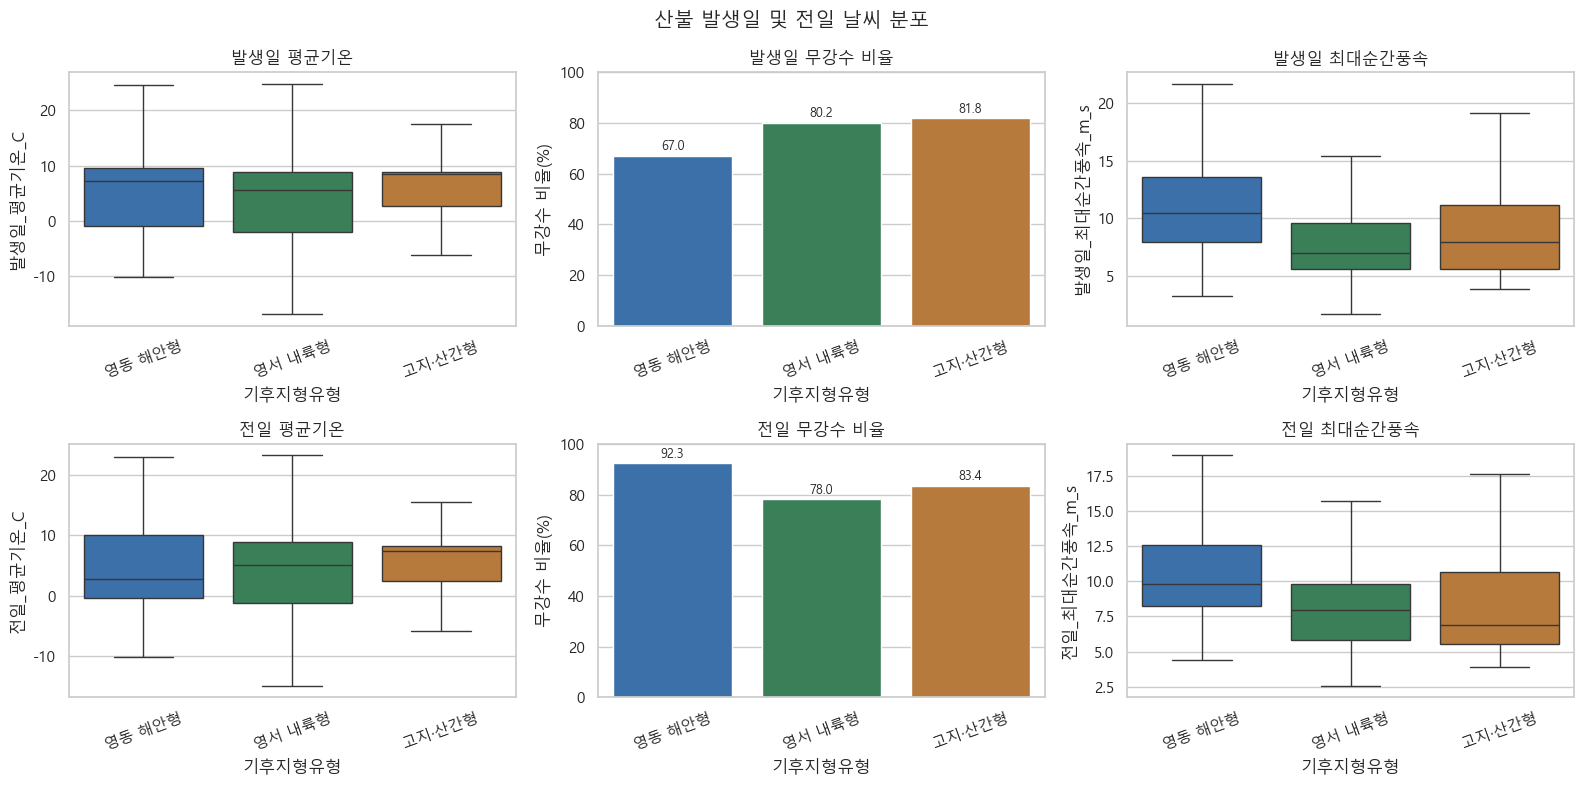

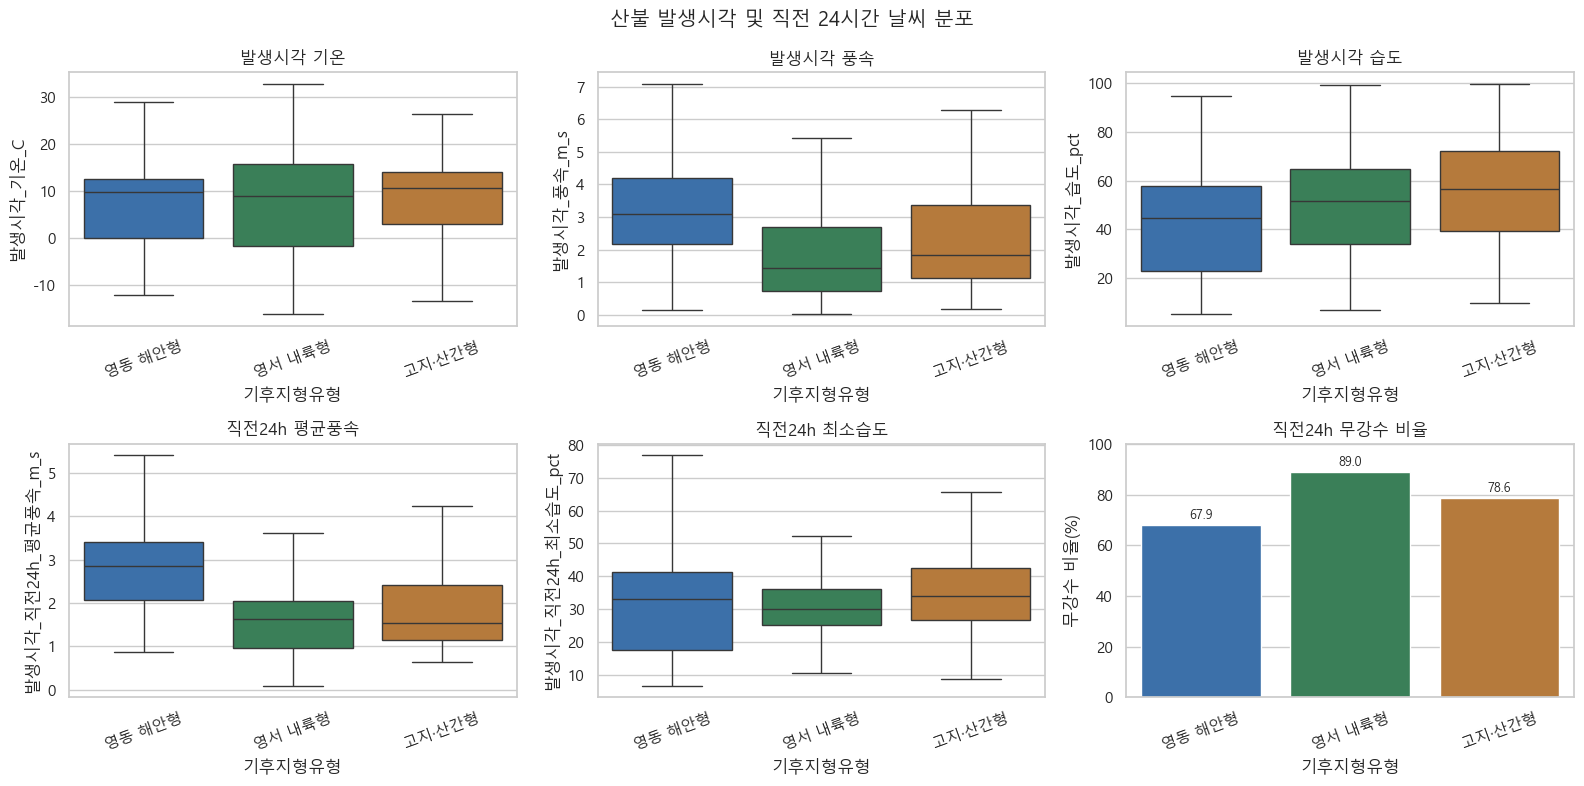

In [8]:
def build_fire_weather(fire_cells, daily, hourly24):
    fire_daily = fire_cells.merge(
        daily.add_prefix("발생일_"),
        left_on=["기상셀ID", "날짜"],
        right_on=["발생일_기상셀ID", "발생일_날짜"],
        how="left",
    )
    fire_daily = fire_daily.merge(
        daily.add_prefix("전일_"),
        left_on=["기상셀ID", "전일"],
        right_on=["전일_기상셀ID", "전일_날짜"],
        how="left",
    )
    fire_hourly = fire_cells.merge(
        hourly24.add_prefix("발생시각_"),
        left_on=["기상셀ID", "발생일시"],
        right_on=["발생시각_기상셀ID", "발생시각_일시"],
        how="left",
    )
    return set_type_order(fire_daily), set_type_order(fire_hourly)


def boxplot_by_type(ax, data, col, title):
    sns.boxplot(
        data=data,
        x="기후지형유형",
        y=col,
        order=TYPE_ORDER,
        palette=TYPE_PALETTE,
        showfliers=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)


def dry_rate_bar_by_type(ax, data, col, title):
    plot_data = data[["기후지형유형", col]].copy()
    plot_data[col] = pd.to_numeric(plot_data[col], errors="coerce")

    dry_rate = (
        plot_data.assign(무강수=plot_data[col].le(0))
        .groupby("기후지형유형", observed=False)["무강수"]
        .mean()
        .reindex(TYPE_ORDER)
        .mul(100)
        .rename("무강수비율_pct")
        .reset_index()
    )

    sns.barplot(
        data=dry_rate,
        x="기후지형유형",
        y="무강수비율_pct",
        order=TYPE_ORDER,
        palette=TYPE_PALETTE,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_ylabel("무강수 비율(%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=20)
    add_value_labels(ax, fmt="{:.1f}")


fire_daily, fire_hourly = build_fire_weather(fire_cells, daily, hourly24)

assert fire_daily["발생일_평균기온_C"].notna().sum() == 3401
assert fire_hourly["발생시각_기온_C"].notna().sum() == 3401


fig, axes = plt.subplots(2, 3, figsize=(16, 8))

boxplot_by_type(
    axes[0, 0],
    fire_daily,
    "발생일_평균기온_C",
    "발생일 평균기온",
)
dry_rate_bar_by_type(
    axes[0, 1],
    fire_daily,
    "발생일_강수량_mm",
    "발생일 무강수 비율",
)
boxplot_by_type(
    axes[0, 2],
    fire_daily,
    "발생일_최대순간풍속_m_s",
    "발생일 최대순간풍속",
)
boxplot_by_type(
    axes[1, 0],
    fire_daily,
    "전일_평균기온_C",
    "전일 평균기온",
)
dry_rate_bar_by_type(
    axes[1, 1],
    fire_daily,
    "전일_강수량_mm",
    "전일 무강수 비율",
)
boxplot_by_type(
    axes[1, 2],
    fire_daily,
    "전일_최대순간풍속_m_s",
    "전일 최대순간풍속",
)

fig.suptitle("산불 발생일 및 전일 날씨 분포")
savefig_show()


fig, axes = plt.subplots(2, 3, figsize=(16, 8))

boxplot_by_type(
    axes[0, 0],
    fire_hourly,
    "발생시각_기온_C",
    "발생시각 기온",
)
boxplot_by_type(
    axes[0, 1],
    fire_hourly,
    "발생시각_풍속_m_s",
    "발생시각 풍속",
)
boxplot_by_type(
    axes[0, 2],
    fire_hourly,
    "발생시각_습도_pct",
    "발생시각 습도",
)
boxplot_by_type(
    axes[1, 0],
    fire_hourly,
    "발생시각_직전24h_평균풍속_m_s",
    "직전24h 평균풍속",
)
boxplot_by_type(
    axes[1, 1],
    fire_hourly,
    "발생시각_직전24h_최소습도_pct",
    "직전24h 최소습도",
)
dry_rate_bar_by_type(
    axes[1, 2],
    fire_hourly,
    "발생시각_직전24h_강수량합_mm",
    "직전24h 무강수 비율",
)

fig.suptitle("산불 발생시각 및 직전 24시간 날씨 분포")
savefig_show()

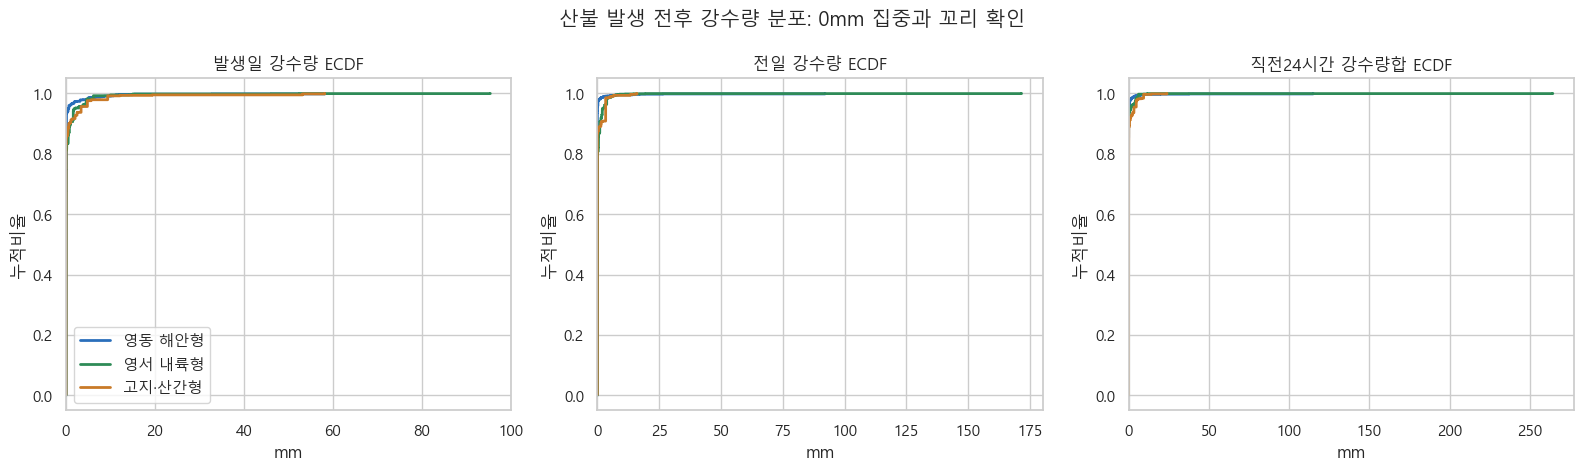

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
rain_specs = [
    (fire_daily, "발생일_강수량_mm", "발생일 강수량 ECDF"),
    (fire_daily, "전일_강수량_mm", "전일 강수량 ECDF"),
    (fire_hourly, "발생시각_직전24h_강수량합_mm", "직전24시간 강수량합 ECDF"),
]
for ax, (data, col, title) in zip(axes, rain_specs):
    for t in TYPE_ORDER:
        s = data.loc[data["기후지형유형"] == t, col].dropna()
        x = np.sort(s.to_numpy())
        y = np.arange(1, len(x) + 1) / len(x)
        ax.step(x, y, where="post", color=TYPE_PALETTE[t], label=t, linewidth=2)
    ax.set_xlim(left=0)
    ax.set_title(title)
    ax.set_xlabel("mm")
    ax.set_ylabel("누적비율")
axes[0].legend()
fig.suptitle("산불 발생 전후 강수량 분포: 0mm 집중과 꼬리 확인")
savefig_show()
        

## 5. 비발생 비교군과 통계 검정 설계

In [10]:
def make_nonfire_sets(fire_cells, daily, hourly24):
    fire_hour_keys = set(zip(fire_cells["기상셀ID"], fire_cells["발생일시"]))
    fire_day_keys = set(zip(fire_cells["기상셀ID"], fire_cells["날짜"]))
    daily_nonfire = daily[~pd.MultiIndex.from_frame(daily[["기상셀ID", "날짜"]]).isin(fire_day_keys)].copy()
    hourly_nonfire = hourly24[~pd.MultiIndex.from_frame(hourly24[["기상셀ID", "일시"]]).isin(fire_hour_keys)].copy()
    return daily_nonfire, hourly_nonfire, fire_hour_keys, fire_day_keys


def build_matched_controls(fire_cells, daily, hourly24, fire_hour_keys, fire_day_keys):
    candidate = hourly24[
        ~pd.MultiIndex.from_frame(hourly24[["기상셀ID", "일시"]]).isin(fire_hour_keys)
        & ~pd.MultiIndex.from_frame(hourly24[["기상셀ID", "날짜"]]).isin(fire_day_keys)
    ][["기상셀ID", "일시", "날짜", "월", "시간"]].copy()

    pools = {
        key: frame.index.to_numpy()
        for key, frame in candidate.groupby(["기상셀ID", "월", "시간"], sort=False)
    }
    rng = np.random.default_rng(RANDOM_STATE)
    rows = []
    for row in fire_cells[["fire_id", "기상셀ID", "월_key", "시간_key"]].itertuples(index=False):
        key = (row.기상셀ID, row.월_key, row.시간_key)
        idx = pools.get(key, np.array([], dtype=int))
        if len(idx) == 0:
            continue
        pick = rng.choice(idx, size=min(5, len(idx)), replace=False)
        selected = candidate.loc[pick, ["기상셀ID", "일시", "날짜"]].copy()
        selected.insert(0, "fire_id", row.fire_id)
        rows.append(selected)

    controls = pd.concat(rows, ignore_index=True)
    controls = controls.merge(
        hourly24.add_prefix("대조시각_"),
        left_on=["기상셀ID", "일시"],
        right_on=["대조시각_기상셀ID", "대조시각_일시"],
        how="left",
    )
    controls = controls.merge(
        daily.add_prefix("대조일_"),
        left_on=["기상셀ID", "날짜"],
        right_on=["대조일_기상셀ID", "대조일_날짜"],
        how="left",
    )
    controls["전일"] = controls["날짜"] - pd.Timedelta(days=1)
    controls = controls.merge(
        daily.add_prefix("대조전일_"),
        left_on=["기상셀ID", "전일"],
        right_on=["대조전일_기상셀ID", "대조전일_날짜"],
        how="left",
    )
    return controls


daily_nonfire, hourly_nonfire, fire_hour_keys, fire_day_keys = make_nonfire_sets(fire_cells, daily, hourly24)
matched_controls = build_matched_controls(fire_cells, daily, hourly24, fire_hour_keys, fire_day_keys)

assert matched_controls["fire_id"].nunique() == len(fire_cells)
assert matched_controls.groupby("fire_id").size().between(1, 5).all()

display(Markdown(
    f'''### 비교군 구성
- 전체 비발생 일단위: **{len(daily_nonfire):,}행**
- 전체 비발생 시간단위: **{len(hourly_nonfire):,}행**
- 매칭 비발생: **{len(matched_controls):,}행**
- 산불 1건당 매칭 비발생 수: **{matched_controls.groupby("fire_id").size().mean():.1f}개**
'''
))
        

### 비교군 구성
- 전체 비발생 일단위: **66,332행**
- 전체 비발생 시간단위: **1,612,898행**
- 매칭 비발생: **17,005행**
- 산불 1건당 매칭 비발생 수: **5.0개**


In [11]:
def cohen_d(a, b):
    a = pd.Series(a).dropna().astype(float)
    b = pd.Series(b).dropna().astype(float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    if pooled == 0:
        return np.nan
    return (a.mean() - b.mean()) / pooled


def mean_ci(diff):
    diff = pd.Series(diff).dropna().astype(float)
    if len(diff) < 2:
        return np.nan, np.nan
    se = diff.std(ddof=1) / np.sqrt(len(diff))
    h = stats.t.ppf(0.975, len(diff) - 1) * se
    return diff.mean() - h, diff.mean() + h


def compare_full(fire_df, control_df, pairs):
    rows = []
    for label, fire_col, control_col, unit, family in pairs:
        a = pd.to_numeric(fire_df[fire_col], errors="coerce").dropna()
        b = pd.to_numeric(control_df[control_col], errors="coerce").dropna()
        if len(a) < 2 or len(b) < 2:
            continue
        rows.append(
            {
                "조건": label,
                "단위": unit,
                "묶음": family,
                "산불_n": len(a),
                "비발생_n": len(b),
                "산불평균": a.mean(),
                "비발생평균": b.mean(),
                "산불중앙값": a.median(),
                "비발생중앙값": b.median(),
                "평균차": a.mean() - b.mean(),
                "Cohen_d": cohen_d(a, b),
                "Welch_p": stats.ttest_ind(a, b, equal_var=False, nan_policy="omit").pvalue,
                "MannWhitney_p": stats.mannwhitneyu(a, b, alternative="two-sided").pvalue,
            }
        )
    out = pd.DataFrame(rows)
    if not out.empty:
        out["Welch_FDR"] = multipletests(out["Welch_p"], method="fdr_bh")[1]
        out["MannWhitney_FDR"] = multipletests(out["MannWhitney_p"], method="fdr_bh")[1]
    return out


def compare_matched(fire_df, control_df, pairs):
    rows = []
    diff_store = {}
    for label, fire_col, control_col, unit, family in pairs:
        ctrl_mean = control_df.groupby("fire_id")[control_col].mean()
        fire_vals = fire_df.set_index("fire_id")[fire_col]
        both = pd.concat([fire_vals.rename("fire"), ctrl_mean.rename("control")], axis=1).dropna()
        diff = both["fire"] - both["control"]
        if len(diff) < 2:
            continue
        try:
            wilcoxon_p = stats.wilcoxon(diff).pvalue
        except ValueError:
            wilcoxon_p = np.nan
        ci_low, ci_high = mean_ci(diff)
        diff_store[label] = diff
        rows.append(
            {
                "조건": label,
                "단위": unit,
                "묶음": family,
                "매칭_n": len(diff),
                "산불평균": both["fire"].mean(),
                "매칭비발생평균": both["control"].mean(),
                "평균차": diff.mean(),
                "CI_low": ci_low,
                "CI_high": ci_high,
                "차이중앙값": diff.median(),
                "Cohen_dz": diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) else np.nan,
                "paired_t_p": stats.ttest_1samp(diff, 0, nan_policy="omit").pvalue,
                "Wilcoxon_p": wilcoxon_p,
            }
        )
    out = pd.DataFrame(rows)
    if not out.empty:
        out["paired_t_FDR"] = multipletests(out["paired_t_p"], method="fdr_bh")[1]
        out["Wilcoxon_FDR"] = multipletests(out["Wilcoxon_p"].fillna(1.0), method="fdr_bh")[1]
    return out, diff_store


daily_full_pairs = [
    ("발생일 평균기온", "발생일_평균기온_C", "평균기온_C", "C", "발생일"),
    ("발생일 강수량", "발생일_강수량_mm", "강수량_mm", "mm", "발생일"),
    ("발생일 최대순간풍속", "발생일_최대순간풍속_m_s", "최대순간풍속_m_s", "m/s", "발생일"),
    ("발생일 서풍계열비율", "발생일_서풍계열_최대순간풍향", "서풍계열_최대순간풍향", "비율", "발생일"),
    ("전일 평균기온", "전일_평균기온_C", "평균기온_C", "C", "전일"),
    ("전일 강수량", "전일_강수량_mm", "강수량_mm", "mm", "전일"),
    ("전일 최대순간풍속", "전일_최대순간풍속_m_s", "최대순간풍속_m_s", "m/s", "전일"),
]
hourly_full_pairs = [
    ("발생시각 기온", "발생시각_기온_C", "기온_C", "C", "발생시각"),
    ("발생시각 풍속", "발생시각_풍속_m_s", "풍속_m_s", "m/s", "발생시각"),
    ("발생시각 습도", "발생시각_습도_pct", "습도_pct", "%p", "발생시각"),
    ("발생시각 현지기압", "발생시각_현지기압_hPa", "현지기압_hPa", "hPa", "발생시각"),
    ("발생시각 서풍계열비율", "발생시각_서풍계열_풍향", "서풍계열_풍향", "비율", "발생시각"),
    ("직전24h 평균풍속", "발생시각_직전24h_평균풍속_m_s", "직전24h_평균풍속_m_s", "m/s", "직전24h"),
    ("직전24h 최대풍속", "발생시각_직전24h_최대풍속_m_s", "직전24h_최대풍속_m_s", "m/s", "직전24h"),
    ("직전24h 최소습도", "발생시각_직전24h_최소습도_pct", "직전24h_최소습도_pct", "%p", "직전24h"),
    ("직전24h 강수량합", "발생시각_직전24h_강수량합_mm", "직전24h_강수량합_mm", "mm", "직전24h"),
    ("직전24h 평균현지기압", "발생시각_직전24h_평균현지기압_hPa", "직전24h_평균현지기압_hPa", "hPa", "직전24h"),
]

fire_all = fire_daily.merge(
    fire_hourly[["fire_id"] + [item[1] for item in hourly_full_pairs]],
    on="fire_id",
    how="left",
)

full_comparison = pd.concat(
    [
        compare_full(fire_daily, daily_nonfire, daily_full_pairs),
        compare_full(fire_hourly, hourly_nonfire, hourly_full_pairs),
    ],
    ignore_index=True,
)

matched_pairs = [
    ("발생일 평균기온", "발생일_평균기온_C", "대조일_평균기온_C", "C", "발생일"),
    ("발생일 강수량", "발생일_강수량_mm", "대조일_강수량_mm", "mm", "발생일"),
    ("발생일 최대순간풍속", "발생일_최대순간풍속_m_s", "대조일_최대순간풍속_m_s", "m/s", "발생일"),
    ("발생일 서풍계열비율", "발생일_서풍계열_최대순간풍향", "대조일_서풍계열_최대순간풍향", "비율", "발생일"),
    ("전일 평균기온", "전일_평균기온_C", "대조전일_평균기온_C", "C", "전일"),
    ("전일 강수량", "전일_강수량_mm", "대조전일_강수량_mm", "mm", "전일"),
    ("전일 최대순간풍속", "전일_최대순간풍속_m_s", "대조전일_최대순간풍속_m_s", "m/s", "전일"),
    ("발생시각 기온", "발생시각_기온_C", "대조시각_기온_C", "C", "발생시각"),
    ("발생시각 풍속", "발생시각_풍속_m_s", "대조시각_풍속_m_s", "m/s", "발생시각"),
    ("발생시각 습도", "발생시각_습도_pct", "대조시각_습도_pct", "%p", "발생시각"),
    ("발생시각 현지기압", "발생시각_현지기압_hPa", "대조시각_현지기압_hPa", "hPa", "발생시각"),
    ("발생시각 서풍계열비율", "발생시각_서풍계열_풍향", "대조시각_서풍계열_풍향", "비율", "발생시각"),
    ("직전24h 평균풍속", "발생시각_직전24h_평균풍속_m_s", "대조시각_직전24h_평균풍속_m_s", "m/s", "직전24h"),
    ("직전24h 최대풍속", "발생시각_직전24h_최대풍속_m_s", "대조시각_직전24h_최대풍속_m_s", "m/s", "직전24h"),
    ("직전24h 최소습도", "발생시각_직전24h_최소습도_pct", "대조시각_직전24h_최소습도_pct", "%p", "직전24h"),
    ("직전24h 강수량합", "발생시각_직전24h_강수량합_mm", "대조시각_직전24h_강수량합_mm", "mm", "직전24h"),
    ("직전24h 평균현지기압", "발생시각_직전24h_평균현지기압_hPa", "대조시각_직전24h_평균현지기압_hPa", "hPa", "직전24h"),
]
matched_comparison, matched_diff_store = compare_matched(fire_all, matched_controls, matched_pairs)
        

## 6. 산불 vs 비발생: 효과크기와 유의성 시각화

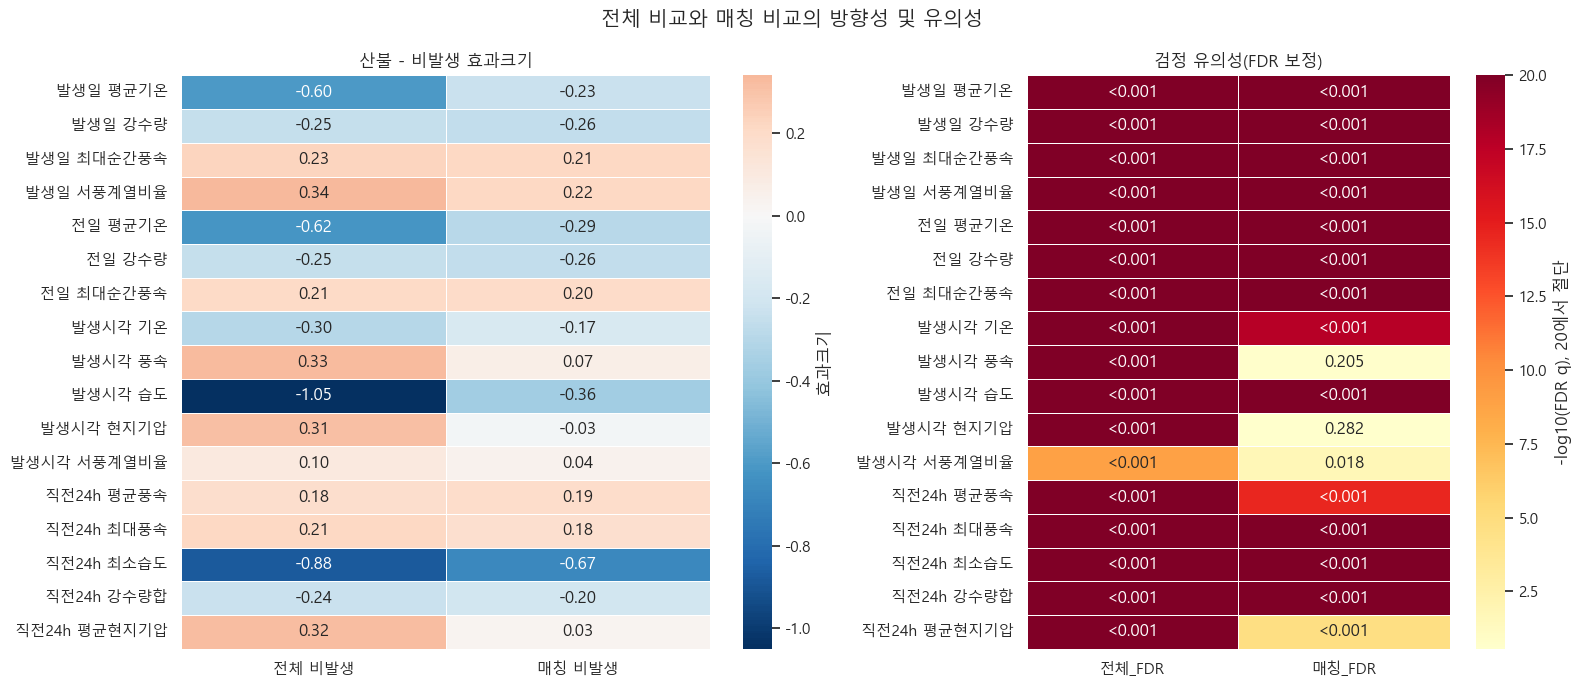

In [12]:
effect = full_comparison[["조건", "묶음", "Cohen_d", "MannWhitney_FDR"]].rename(columns={"Cohen_d": "전체 비발생", "MannWhitney_FDR": "전체_FDR"})
effect = effect.merge(
    matched_comparison[["조건", "Cohen_dz", "Wilcoxon_FDR"]].rename(columns={"Cohen_dz": "매칭 비발생", "Wilcoxon_FDR": "매칭_FDR"}),
    on="조건",
    how="left",
)
effect = effect.set_index("조건").loc[[p[0] for p in matched_pairs if p[0] in effect["조건"].values]]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.0, 0.8]})
sns.heatmap(
    effect[["전체 비발생", "매칭 비발생"]],
    center=0,
    cmap="RdBu_r",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "효과크기"},
    ax=axes[0],
)
axes[0].set_title("산불 - 비발생 효과크기")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

q_plot = effect[["전체_FDR", "매칭_FDR"]].clip(lower=1e-300)
neglogq = -np.log10(q_plot)
neglogq = neglogq.clip(upper=20)
sns.heatmap(
    neglogq,
    cmap="YlOrRd",
    annot=q_plot.map(lambda x: "<0.001" if x < 0.001 else f"{x:.3f}"),
    fmt="",
    linewidths=0.5,
    cbar_kws={"label": "-log10(FDR q), 20에서 절단"},
    ax=axes[1],
)
axes[1].set_title("검정 유의성(FDR 보정)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
fig.suptitle("전체 비교와 매칭 비교의 방향성 및 유의성")
savefig_show()
        

- 전체 비발생(독립표본) : 산불 발생과 전체 비발생 데이터의 Cohen's d(두 집간 평균 차이/표준편차)
  - 음수일 경우 비발생 쪽이 크다는 의미
- 매칭 비발생(쌍비교) : 산불 발생데이터와 같은 월, 지역, 비슷한 조건을 맞춘 Cohen's d
  
- 전체_FDR : Mann-Whitney U 검정의 p-value를 FDR 보정
  - FDR(False Discovery Rate) : 수많은 변수 중 우연히 유의하게 나오는 변수들을 제거
  - 값이 낮을수록 매우 유의
- 매칭_FDR : Wilcoxon signed-rank test의 p-value를 FDR 보정

- 산불 발생 시점은 일반 비발생 시점보다 훨씬 건조하고, 기온이 낮으며, 바람이 강한 조건에서 발생하는 경향이 강하다
  - 이것은 매칭 비교에서도 대부분 유지되는 경향을 볼 수 있다.  
  - 특히 습도가 음수이므로 산불 발생 시 습도가 매우 낮다 - 특히 직전 24시간 최소습도  
  - 이때 FDR도 낮으므로 통계적으로 매우 유의하다  
- 풍속은 유의하지 않다 -> 단순히 바람이 세서 일수도  
  - 그러나 최대 풍속은 유지됨 - 스케일을 전체로 잡아서 이거는 분류가 필요해보임  

- 강수량은 유의 -> 비가 적게 온 조건에서 산불 발생  
  - 그러나 습도보다는 효과가 약함  
  - 즉 직접적인 건조 상태가 중요  

- 기온은 상대적으로 저온 조건에서 산불이 발생한다  
  - 더울수록 발생한다는 통념에서 벗어난다  
  - 이것은 시기(2월, 10월)적인 요인과 강원도의 특성과 관련지어 추가 분석이 필요하다  


- 서풍 계열 비율이 산불이 발생할때 더 많이 불었다.  
  - 즉 양간지풍의 영향이 있을 거라고 추정할 수 있다.  

- 현지 기압은 전체일때는 꽤 있었지만 매칭했을때는 사라진다


강원도 산불은 전반적으로 낮은 습도와 적은 강수량, 높은 풍속 조건에서 발생하는 경향을 보였다. 특히 직전 24시간 최소습도와 발생시각 습도는 전체 비교 및 시공간 매칭 비교 모두에서 큰 효과크기와 높은 통계적 유의성을 나타내어, 산불 발생과 가장 밀접한 기상 요인으로 확인되었다. 반면 평균 풍속 및 현지기압은 매칭 비교에서 유의성이 감소하여 계절적·지역적 영향이 일부 반영된 결과로 해석된다.

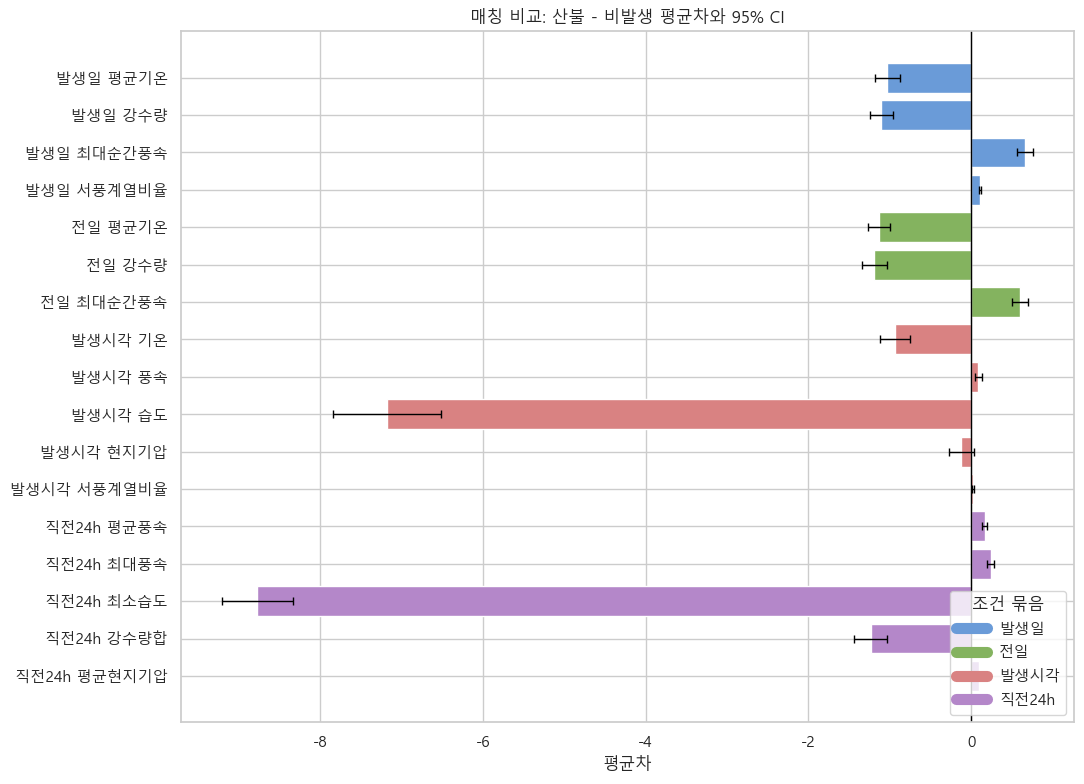

In [13]:
bar_df = matched_comparison.copy()
bar_df["조건"] = pd.Categorical(bar_df["조건"], categories=[p[0] for p in matched_pairs], ordered=True)
bar_df = bar_df.sort_values("조건")

fig, ax = plt.subplots(figsize=(11, 8))
y = np.arange(len(bar_df))
colors = bar_df["묶음"].map({"발생일": "#6A9BD8", "전일": "#84B35F", "발생시각": "#D98282", "직전24h": "#B487C9"})
ax.barh(y, bar_df["평균차"], color=colors)
ax.errorbar(
    bar_df["평균차"],
    y,
    xerr=[bar_df["평균차"] - bar_df["CI_low"], bar_df["CI_high"] - bar_df["평균차"]],
    fmt="none",
    ecolor="black",
    capsize=3,
    linewidth=1,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(bar_df["조건"])
ax.invert_yaxis()
ax.set_title("매칭 비교: 산불 - 비발생 평균차와 95% CI")
ax.set_xlabel("평균차")
legend_handles = [
    plt.Line2D([0], [0], color=color, lw=8, label=label)
    for label, color in {"발생일": "#6A9BD8", "전일": "#84B35F", "발생시각": "#D98282", "직전24h": "#B487C9"}.items()
]
ax.legend(handles=legend_handles, title="조건 묶음", loc="lower right")
savefig_show()
        

0보다 낮으면 산불일 때 값이 더 낮다는 의미

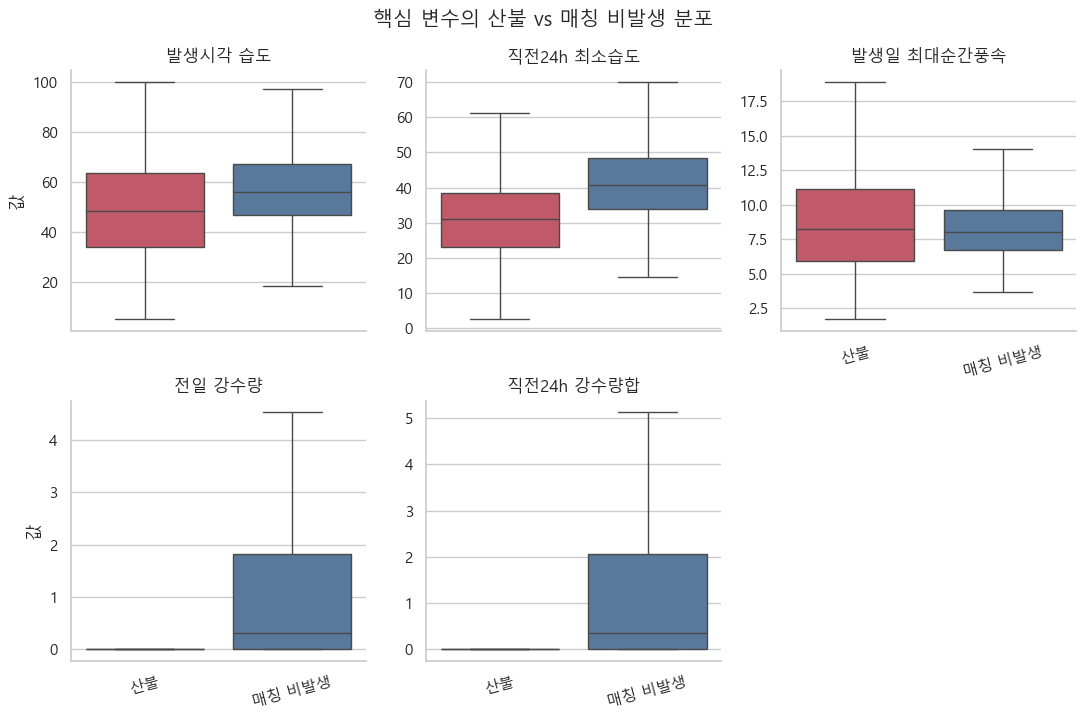

In [14]:
key_pairs = [
    ("발생시각 습도", "발생시각_습도_pct", "대조시각_습도_pct", "%"),
    ("직전24h 최소습도", "발생시각_직전24h_최소습도_pct", "대조시각_직전24h_최소습도_pct", "%"),
    ("발생일 최대순간풍속", "발생일_최대순간풍속_m_s", "대조일_최대순간풍속_m_s", "m/s"),
    ("전일 강수량", "전일_강수량_mm", "대조전일_강수량_mm", "mm"),
    ("직전24h 강수량합", "발생시각_직전24h_강수량합_mm", "대조시각_직전24h_강수량합_mm", "mm"),
]

dist_rows = []
for label, fire_col, control_col, unit in key_pairs:
    fire_vals = fire_all.set_index("fire_id")[fire_col]
    ctrl_vals = matched_controls.groupby("fire_id")[control_col].mean()
    both = pd.concat([fire_vals.rename("산불"), ctrl_vals.rename("매칭 비발생")], axis=1).dropna()
    for group in FIRE_CONTROL_ORDER:
        tmp = pd.DataFrame({"조건": label, "구분": group, "값": both[group].values, "단위": unit})
        dist_rows.append(tmp)
dist_long = pd.concat(dist_rows, ignore_index=True)

g = sns.catplot(
    data=dist_long,
    x="구분",
    y="값",
    col="조건",
    col_wrap=3,
    kind="box",
    order=FIRE_CONTROL_ORDER,
    palette=FIRE_CONTROL_PALETTE,
    showfliers=False,
    height=3.5,
    aspect=1.05,
    sharey=False,
)
g.set_titles("{col_name}")
g.set_axis_labels("", "값")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=15)
g.fig.suptitle("핵심 변수의 산불 vs 매칭 비발생 분포", y=1.03)
plt.show()
        

산불 발생 시점은 매칭 비발생보다 더 건조하고, 비가 적으며, 일부 풍속은 더 강하다.

## 7. 기후지형유형 간 차이: 통계 검정 보강

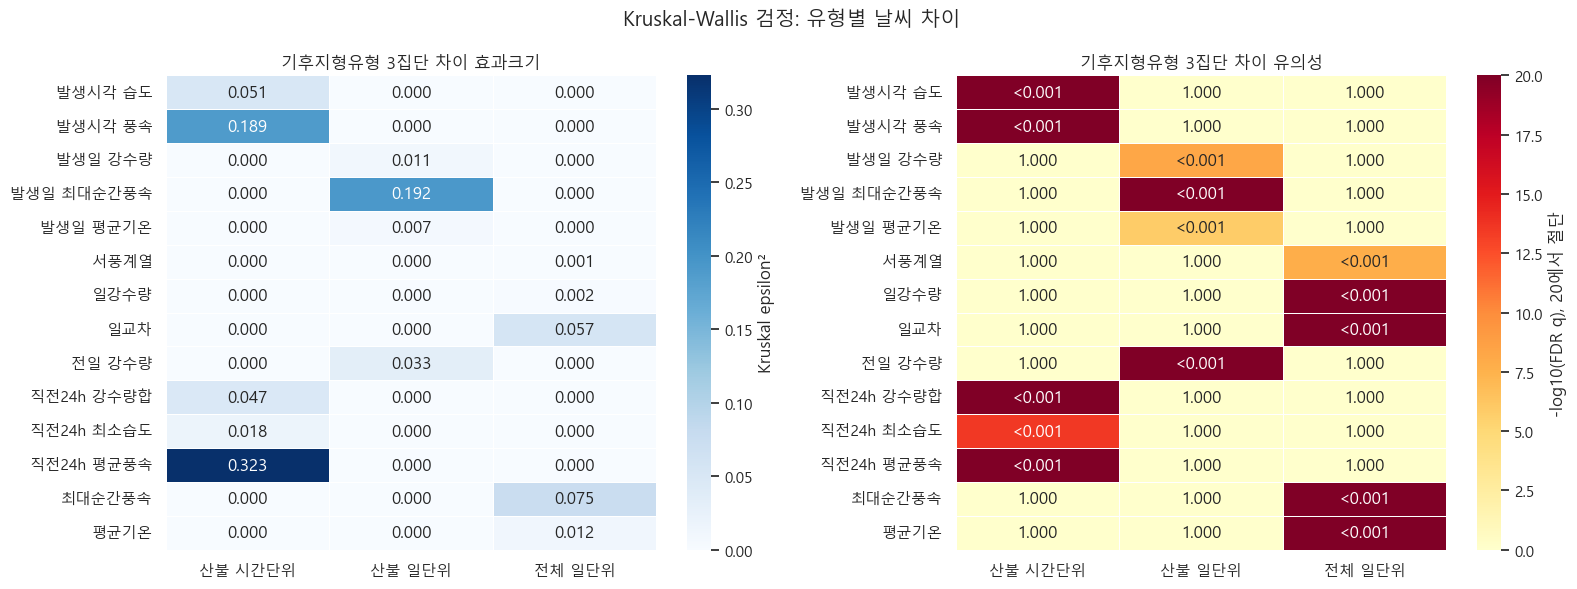

In [15]:
def kruskal_type_tests(df, var_map, label):
    rows = []
    for var_label, col in var_map:
        groups = [pd.to_numeric(df.loc[df["기후지형유형"] == t, col], errors="coerce").dropna() for t in TYPE_ORDER]
        groups = [g for g in groups if len(g) >= 2]
        if len(groups) < 3:
            continue
        h, p = stats.kruskal(*groups)
        n = sum(len(g) for g in groups)
        k = len(groups)
        eps2 = max((h - k + 1) / (n - k), 0) if n > k else np.nan
        rows.append({"분석대상": label, "변수": var_label, "H": h, "p": p, "epsilon2": eps2})
    out = pd.DataFrame(rows)
    if not out.empty:
        out["FDR"] = multipletests(out["p"], method="fdr_bh")[1]
    return out


def pairwise_type_tests(df, var_map, label):
    rows = []
    pairs = [("영동 해안형", "영서 내륙형"), ("영동 해안형", "고지·산간형"), ("영서 내륙형", "고지·산간형")]
    for var_label, col in var_map:
        for a_name, b_name in pairs:
            a = pd.to_numeric(df.loc[df["기후지형유형"] == a_name, col], errors="coerce").dropna()
            b = pd.to_numeric(df.loc[df["기후지형유형"] == b_name, col], errors="coerce").dropna()
            if len(a) < 2 or len(b) < 2:
                continue
            rows.append(
                {
                    "분석대상": label,
                    "변수": var_label,
                    "비교": f"{a_name} - {b_name}",
                    "평균차": a.mean() - b.mean(),
                    "Cohen_d": cohen_d(a, b),
                    "p": stats.mannwhitneyu(a, b, alternative="two-sided").pvalue,
                }
            )
    out = pd.DataFrame(rows)
    if not out.empty:
        out["FDR"] = multipletests(out["p"], method="fdr_bh")[1]
    return out


background_vars = [
    ("평균기온", "평균기온_C"),
    ("일교차", "일교차_C"),
    ("일강수량", "강수량_mm"),
    ("최대순간풍속", "최대순간풍속_m_s"),
    ("서풍계열", "서풍계열_최대순간풍향"),
]
fire_day_vars = [
    ("발생일 평균기온", "발생일_평균기온_C"),
    ("발생일 강수량", "발생일_강수량_mm"),
    ("발생일 최대순간풍속", "발생일_최대순간풍속_m_s"),
    ("전일 강수량", "전일_강수량_mm"),
]
fire_hour_vars = [
    ("발생시각 풍속", "발생시각_풍속_m_s"),
    ("발생시각 습도", "발생시각_습도_pct"),
    ("직전24h 평균풍속", "발생시각_직전24h_평균풍속_m_s"),
    ("직전24h 최소습도", "발생시각_직전24h_최소습도_pct"),
    ("직전24h 강수량합", "발생시각_직전24h_강수량합_mm"),
]

type_kw = pd.concat(
    [
        kruskal_type_tests(daily, background_vars, "전체 일단위"),
        kruskal_type_tests(fire_daily, fire_day_vars, "산불 일단위"),
        kruskal_type_tests(fire_hourly, fire_hour_vars, "산불 시간단위"),
    ],
    ignore_index=True,
)
type_pairwise = pd.concat(
    [
        pairwise_type_tests(daily, background_vars, "전체 일단위"),
        pairwise_type_tests(fire_daily, fire_day_vars, "산불 일단위"),
        pairwise_type_tests(fire_hourly, fire_hour_vars, "산불 시간단위"),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
kw_effect = type_kw.pivot(index="변수", columns="분석대상", values="epsilon2").fillna(0)
sns.heatmap(kw_effect, cmap="Blues", annot=True, fmt=".3f", linewidths=0.5, cbar_kws={"label": "Kruskal epsilon²"}, ax=axes[0])
axes[0].set_title("기후지형유형 3집단 차이 효과크기")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

kw_q = type_kw.pivot(index="변수", columns="분석대상", values="FDR").fillna(1).clip(lower=1e-300)
kw_neglog = (-np.log10(kw_q)).clip(upper=20)
sns.heatmap(
    kw_neglog,
    cmap="YlOrRd",
    annot=kw_q.map(lambda x: "<0.001" if x < 0.001 else f"{x:.3f}"),
    fmt="",
    linewidths=0.5,
    cbar_kws={"label": "-log10(FDR q), 20에서 절단"},
    ax=axes[1],
)
axes[1].set_title("기후지형유형 3집단 차이 유의성")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
fig.suptitle("Kruskal-Wallis 검정: 유형별 날씨 차이")
savefig_show()
        

-  kruskal-wallis : 기후지형유형(영동 해안형 / 영서 내륙형 / 고지·산간형)이 해당 변수 차이를 얼마나 설명하는가
   - 산불 시간단위에서 효과 크기 차이가 제일 크다
     - 직전24h 평균풍속과 발생시각 풍속 -> 풍속은 기후지형 영향을 많이 받는다
   - 습도에서도 유형 차이 존재
     - 풍속만큼 차이가 크진 않음
   - 산불 일단위에서는 발생일 최대순간풍속이 중요함
     - 영동은 더 강한 돌풍형 산불일 가능성 존재
- 즉 산불 기상 특성은 기후지형유형에 따라 달라진다

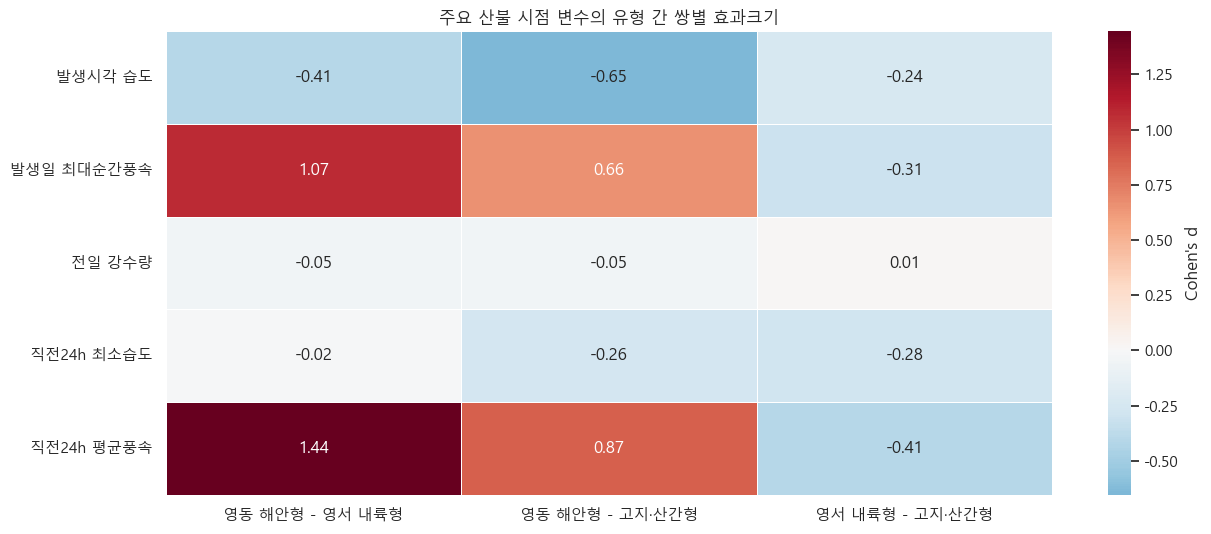

In [16]:
selected_pairwise = type_pairwise[type_pairwise["변수"].isin(["발생일 최대순간풍속", "발생시각 습도", "직전24h 최소습도", "직전24h 평균풍속", "전일 강수량"])].copy()
if not selected_pairwise.empty:
    selected_pairwise["비교"] = pd.Categorical(
        selected_pairwise["비교"],
        categories=[
            "영동 해안형 - 영서 내륙형",
            "영동 해안형 - 고지·산간형",
            "영서 내륙형 - 고지·산간형",
        ],
        ordered=True,
    )
    pair_heat = selected_pairwise.pivot_table(index="변수", columns="비교", values="Cohen_d", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(13, 5.5))
    sns.heatmap(pair_heat, center=0, cmap="RdBu_r", annot=True, fmt=".2f", linewidths=0.5, cbar_kws={"label": "Cohen's d"}, ax=ax)
    ax.set_title("주요 산불 시점 변수의 유형 간 쌍별 효과크기")
    ax.set_xlabel("")
    ax.set_ylabel("")
    savefig_show()
        

- Cohen's d, 어느쪽 값이 더 큰지
  - +면 앞쪽 범주가 더 크다

| 변수         | 주요 결과                                            | 해석                               |
| ---------- | ------------------------------------------------ | -------------------------------- |
| 직전24h 평균풍속 | 영동 해안형 > 영서 내륙형 `1.44`, 영동 해안형 > 고지·산간형 `0.87`   | 영동 해안형 산불은 발생 전 24시간 평균풍속이 훨씬 강함 |
| 발생일 최대순간풍속 | 영동 해안형 > 영서 내륙형 `1.07`, 영동 해안형 > 고지·산간형 `0.66`   | 영동 해안형은 돌풍/순간풍속이 강한 산불 특성이 뚜렷함   |
| 발생시각 습도    | 영동 해안형 < 영서 내륙형 `-0.41`, 영동 해안형 < 고지·산간형 `-0.65` | 영동 해안형 산불 시점이 더 건조함              |
| 직전24h 최소습도 | 영동 해안형과 영서 내륙형은 거의 차이 없음, 영동/영서 모두 고지·산간형보다 낮음   | 고지·산간형은 최소습도가 상대적으로 높음           |
| 전일 강수량     | 거의 차이 없음                                         | 유형별 차이가 거의 없음                    |

영동 해안형 산불은 다른 유형보다 풍속이 훨씬 강하고, 발생시각 습도는 더 낮은 편이다.  
반면 전일 강수량은 유형 간 차이가 거의 없습니다.

## 8. 변수 간 관계: 산불 발생 시점의 복합 조건

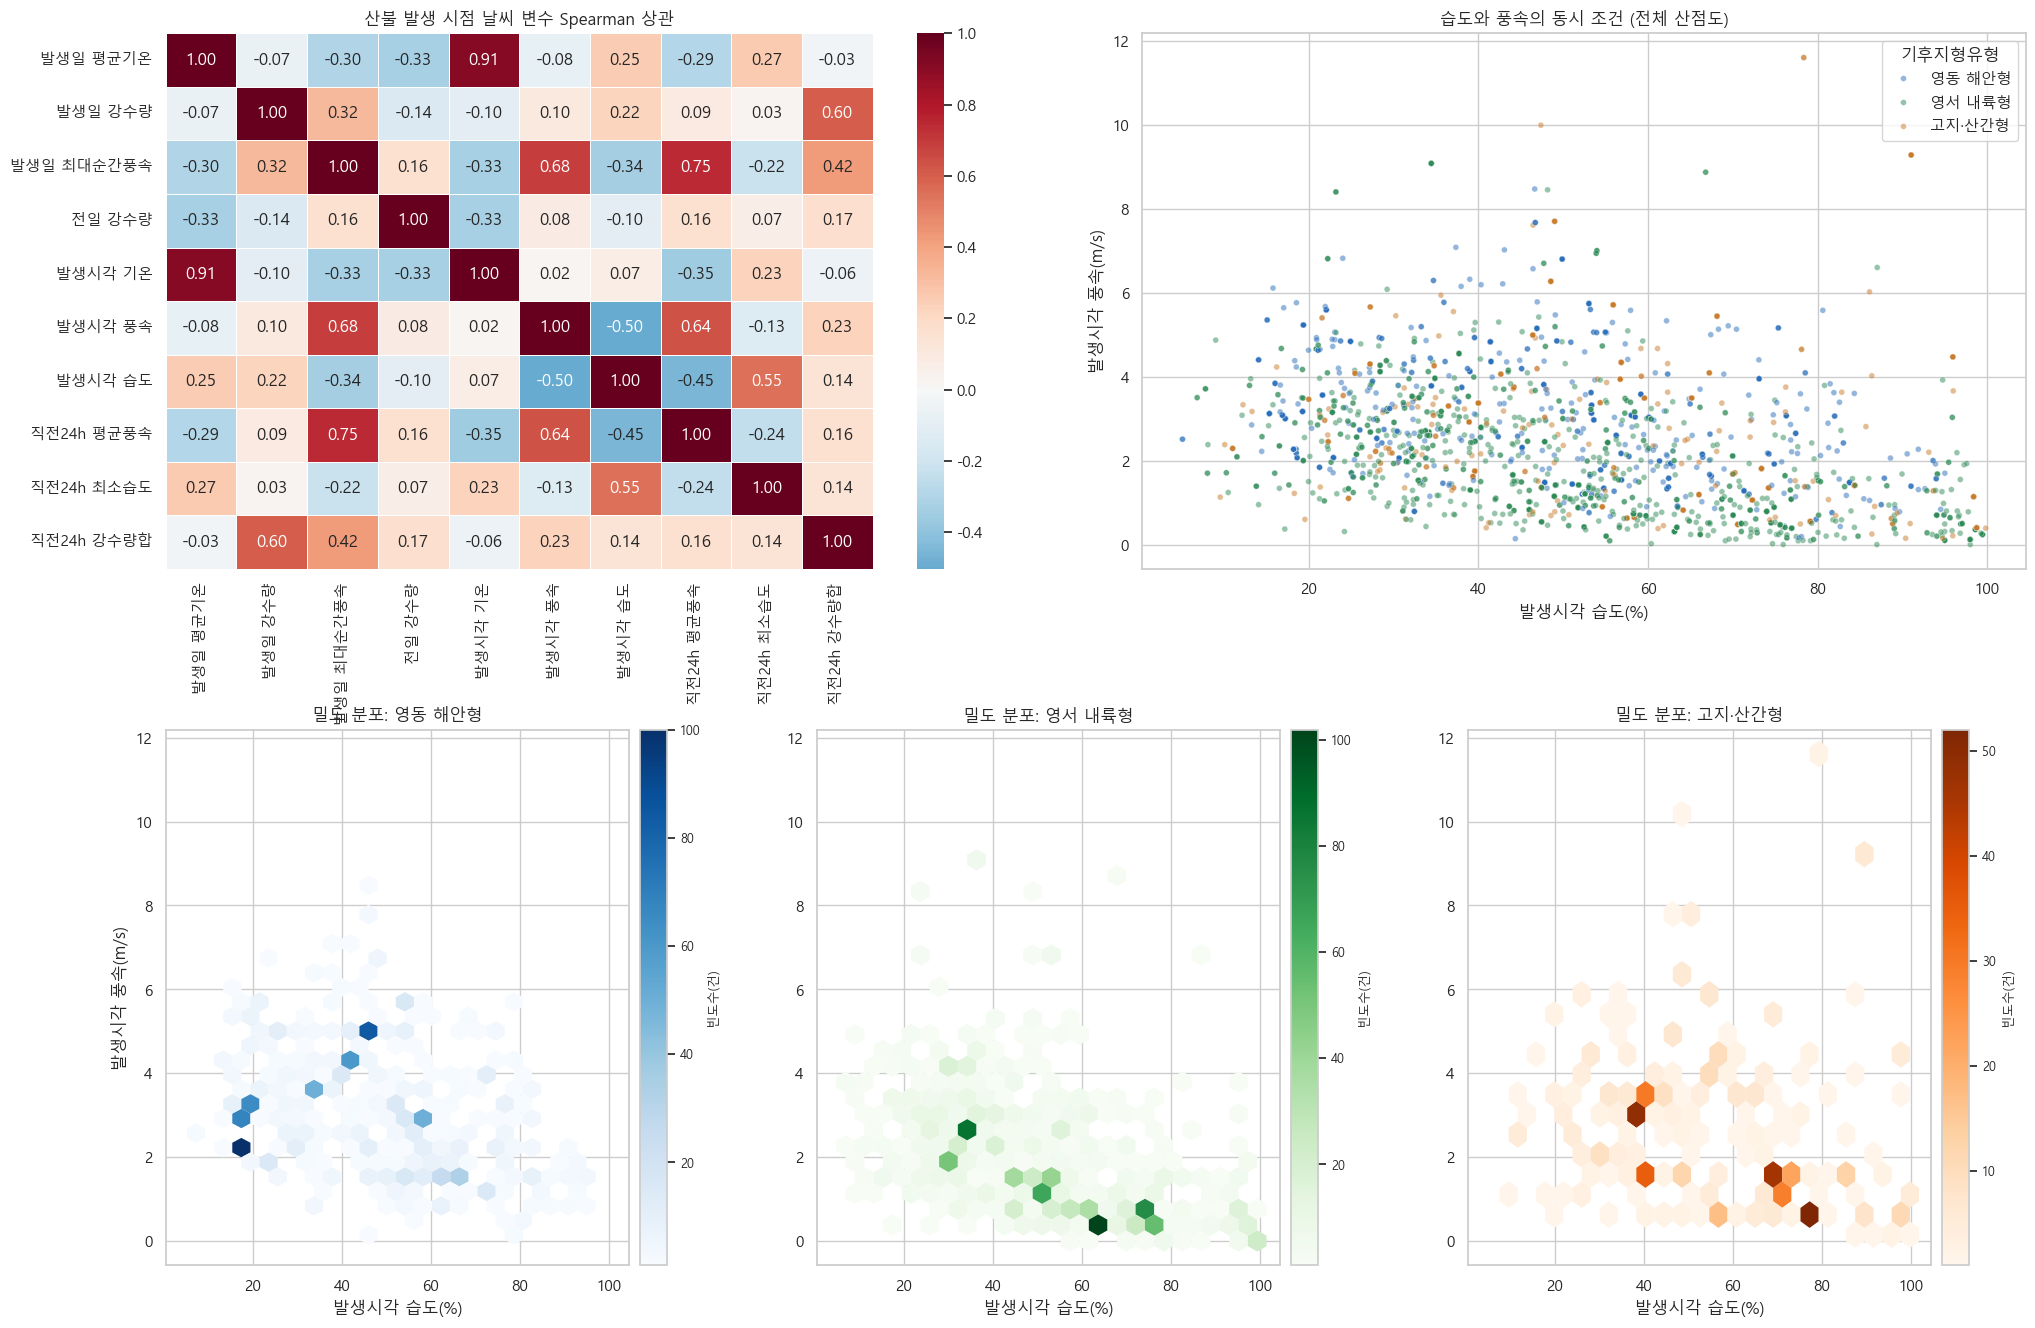

In [28]:
# 1. 데이터 추출 및 변수명 변경
fire_feature_cols = {
    "발생일 평균기온": "발생일_평균기온_C",
    "발생일 강수량": "발생일_강수량_mm",
    "발생일 최대순간풍속": "발생일_최대순간풍속_m_s",
    "전일 강수량": "전일_강수량_mm",
    "발생시각 기온": "발생시각_기온_C",
    "발생시각 풍속": "발생시각_풍속_m_s",
    "발생시각 습도": "발생시각_습도_pct",
    "직전24h 평균풍속": "발생시각_직전24h_평균풍속_m_s",
    "직전24h 최소습도": "발생시각_직전24h_최소습도_pct",
    "직전24h 강수량합": "발생시각_직전24h_강수량합_mm",
}

fire_features = fire_all[["fire_id"] + list(fire_feature_cols.values())].rename(
    columns={v: k for k, v in fire_feature_cols.items()}
)

scatter_data = fire_all.merge(
    fire_cells[["fire_id", "기후지형유형"]],
    on="fire_id",
    suffixes=("", "_fire")
)

# 2. Figure 레이아웃 설정
fig = plt.figure(figsize=(24, 16))
gs = fig.add_gridspec(2, 6, height_ratios=[1, 1], hspace=0.3, wspace=0.4)

ax_corr = fig.add_subplot(gs[0, 0:3])
ax_scat = fig.add_subplot(gs[0, 3:6])

ax_hex1 = fig.add_subplot(gs[1, 0:2])
ax_hex2 = fig.add_subplot(gs[1, 2:4], sharex=ax_hex1, sharey=ax_hex1)
ax_hex3 = fig.add_subplot(gs[1, 4:6], sharex=ax_hex1, sharey=ax_hex1)
axes_hex = [ax_hex1, ax_hex2, ax_hex3]

# 3. Spearman 상관 heatmap
corr = fire_features.drop(columns=["fire_id"]).corr(method="spearman")

sns.heatmap(
    corr,
    center=0,
    cmap="RdBu_r",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=ax_corr
)

ax_corr.set_title("산불 발생 시점 날씨 변수 Spearman 상관")

# 4. 전체 산점도: 발생시각 습도 vs 발생시각 풍속
sns.scatterplot(
    data=scatter_data,
    x="발생시각_습도_pct",
    y="발생시각_풍속_m_s",
    hue="기후지형유형",
    hue_order=TYPE_ORDER,
    palette=TYPE_PALETTE,
    alpha=0.5,
    s=18,
    ax=ax_scat,
)

ax_scat.set_title("습도와 풍속의 동시 조건 (전체 산점도)")
ax_scat.set_xlabel("발생시각 습도(%)")
ax_scat.set_ylabel("발생시각 풍속(m/s)")
ax_scat.legend(title="기후지형유형")

# 5. 기후지형유형별 Hexbin 밀도 분포
cmaps = {
    "영동 해안형": "Blues",
    "영서 내륙형": "Greens",
    "고지·산간형": "Oranges"
}

for i, dtype in enumerate(TYPE_ORDER):
    sub_data = scatter_data[scatter_data["기후지형유형"] == dtype]

    hb = axes_hex[i].hexbin(
        sub_data["발생시각_습도_pct"],
        sub_data["발생시각_풍속_m_s"],
        gridsize=22,
        cmap=cmaps[dtype],
        mincnt=1,
        edgecolors="none"
    )

    axes_hex[i].set_title(f"밀도 분포: {dtype}")
    axes_hex[i].set_xlabel("발생시각 습도(%)")

    if i == 0:
        axes_hex[i].set_ylabel("발생시각 풍속(m/s)")

    cb = fig.colorbar(hb, ax=axes_hex[i], orientation="vertical", pad=0.02)
    cb.ax.tick_params(labelsize=9)
    cb.set_label("빈도수(건)", fontsize=9)

savefig_show()

- 습도와 풍속은 음의 상관
  - 바람이 강할수록 습도가 낮은 경향, 건조한 양간지풍
- 직전24h 평균풍속 ↔ 발생시각 풍속 강한 양의 상관
  - 산불이 발생했을 때 바람이 강했던 경우는 직전 24시간전부터 지속적인 강풍 환경이였던 것
- 직전24h 최소습도 ↔ 발생시각 습도도 강한 양의 상관
  - 습도도 계속 전날부터 건조했었던 것
- 우상단의 그래프를 보면 산불은 대체로 습도가 낮으며 풍속이 중간일 때 위치한다
- 영동지방의 경우 저습 강풍의 조합이 많이 보인다
  - 양간지풍이 확연히 보인다
- 영서는 영동보다 습도의 범위가 더 넓으며 바람의 세기가 더 약하다
  - 바람에 의한 강제 확산보다는, 분지 지형 특유의 대기 정체와 복사열로 인해 가연물(낙엽 등)이 바짝 마르는 '극심한 건조도'
- 고지 산간형은 분포의 분산이 크며 영서랑 비슷한 패턴을 보여준다
  - 해발고도가 높아 기온이 낮기 때문에 상대습도 하한선이 내륙만큼 극단적으로 떨어지지는 않지만, 고지대 특유의 지형성 풍속 유도가 결합되어 독특한 중간 형태의 밀도 분포
- 즉 셋 모두 습도가 낮으면 바람의 세기가 5m/s보다 낮더라도 산불이 발생할 가능성이 높다는 것이다

## 9. 최종 요약

본 분석은 강원도 기상 격자 데이터(일단위, 시간단위)와 산불 발생 이력 데이터를 결합하여 산불 발생 시점의 날씨 특성을 규명하고, 세 가지 기후지형유형(`영동 해안형`, `영서 내륙형`, `고지·산간형`)별 기상 차이 및 대조군 대비 산불 발생 시점의 기상 이례성을 통계적으로 검증하였다.

### 1) 산불 발생의 시공간적 분포 특성
- **계절성 및 유형별 차이**: 강원도 산불은 2월(늦겨울)과 10월(가을)에 빈번하게 발생하는 쌍봉형 분포를 띤다. 특히 **영동 해안형**은 산불의 56%가 2월에 집중되는 반면, **고지·산간형**은 가을철(10월) 발생 비중이 41%로 겨울철(2월, 33%)보다 높게 나타나 유형별 산불 위험 시기가 상이함을 보여준다.
- **시간대별 분포**: 하루 중 산불 발생은 기온이 상승하고 대기가 건조해지는 오전 10~11시 및 오후 1~2시에 집중된다.

### 2) 산불 vs 매칭 비발생 시점 날씨 차이 검정 (이례성 분석)
- **강수량**: ECDF 분석 결과, 산불 발생 사건의 약 95% 이상에서 당일 및 전일 강수량이 0mm로 확인되어, 선행 강수의 부재가 산불 발생의 필수적인 배경 조건임이 확인되었다.
- **습도**: 산불 발생 시점은 동일한 지역, 월, 시간대의 대조군(매칭 비발생 시점)보다 **발생시각 습도는 평균 7.2%p, 직전 24시간 최소습도는 8.8%p 유의하게 낮았다** (Cohen's dz 각각 -0.36, -0.67). 저습 조건은 산불 발생 여부를 결정짓는 가장 일관되고 강한 기상학적 신호이다.
- **풍속의 특징**: 산불 발생 시각 정각의 풍속 차이는 매칭 대조군 대비 통계적으로 유의하지 않았으나(q = 0.205), **발생일 최대순간풍속은 평균 0.66m/s, 직전 24시간 평균풍속은 0.17m/s 더 높았다** (q < 0.001). 이는 정각의 일시적 바람보다 해당 날 전체의 기압 배치와 풍속 환경이 산불 발생 및 확산에 더 중요한 역할을 함을 시사한다.
- **온도의 특징**: 산불 발생일은 대조군 대비 평균기온이 약 1.0°C 유의하게 낮았다. 이는 한랭건조한 대륙고기압 확장(서풍 계열 유입) 시기에 산불 위험이 극대화된다는 기상학적 특징을 반영한다.

### 3) 기후지형유형 간 날씨 분포 차이 (양간지풍 효과 검증)
- **영동 해안형의 극단적 기상 조건**: 세 가지 기후지형유형 중 **영동 해안형**은 산불 발생 시점의 **직전 24시간 평균풍속 및 최대순간풍속이 타 유형 대비 압도적으로 높고**(영서 내륙형 대비 d = 1.44, 1.07), **습도가 가장 낮게 형성**되었다(고지·산간형 대비 d = -0.65).
- **양간지풍(Föhn)의 시각화**: 습도와 최대순간풍속의 산점도 분석을 통해, 영동 해안형 산불이 초강풍(10~20m/s)과 초저습도(10~40%)가 동시에 겹치는 우상단/좌상단 극한 영역에 매우 조밀하게 군집해 있음이 관찰되었다. 이는 태백산맥을 넘어 내려오는 강한 한랭건조풍인 **양간지풍 효과**가 영동 해안 지역의 주요 산불 원인임을 데이터로 입증한다.

---

## 10. 향후 분석 방향 및 제언

본 분석 결과를 바탕으로 산불 예측력 향상 및 방재 대책 수립을 위해 다음과 같은 추가 분석 방향을 제안한다.

1. **기상 복합 요인을 반영한 산불 발생 확률 모델링 (Spatiotemporal Machine Learning)**
   - 현재 단변량 검정과 상관분석 수준에서 나아가, 최소습도, 누적 강수량, 평균 풍속 등을 독립변수로 하는 다변량 로지스틱 회귀 분석 및 머신러닝 모델(XGBoost, Random Forest 등)을 구축하여 복합 기상 요인에 따른 산불 발생 확률지수(Fire Probability Index)를 모델링할 필요가 있다.
2. **종관 기압 패턴(Synoptic Weather Patterns)과의 연계**
   - 양간지풍 효과가 영동 해안 지역 산불에 미치는 지대한 영향이 입증되었으므로, 한반도 주변 기압 패턴(남고북저형 기압 배치 등) 데이터를 수집하여 어떤 종관 기압 상태에서 영동/고지 지역의 풍속과 건조도가 임계치를 초과하는지 규명해야 한다.
3. **가을철(10월) 고지·산간형 산불의 특이 원인 규명**
   - 고지·산간형에서 10월에 산불이 집중(41%)되는 현상과 관련하여, 가을철 등산객 증가 등 인적 요인(입산자 수 데이터) 및 가을철 임상(낙엽송 등 연료 습도) 특성과의 상호작용을 정밀 분석해야 한다.
4. **산림 임상(Forest Fuel Types) 및 지형 변수와의 결합**
   - 기상 변수 외에 소나무림 등 침엽수림 분포(임상도 데이터)와 경사도/사면 방향(DEM 파생 변수)을 격자 단위로 결합하여, 특정 기상 조건 하에서 산불이 대형 산불(양간지풍 확산)로 확산될 가능성이 높은 취약 지역을 공간적으로 맵핑해야 한다.
